In [1]:
!pip install pandas numpy matplotlib seaborn plotly folium streamlit openpyxl
!pip install nbformat --upgrade

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [5]:
df = pd.read_csv('Nassau Candy Distributor.csv')

print(f"✅ Dataset loaded!")
print(f"📊 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

✅ Dataset loaded!
📊 Shape: 10194 rows × 18 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [7]:
print("=" * 50)
print("COLUMN NAMES & DATA TYPES")
print("=" * 50)
print(df.dtypes)

print("\n" + "=" * 50)
print("MISSING VALUES PER COLUMN")
print("=" * 50)
print(df.isnull().sum())

print("\n" + "=" * 50)
print("BASIC STATISTICS")
print("=" * 50)
df.describe()

COLUMN NAMES & DATA TYPES
Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID         int64
Country/Region        str
City                  str
State/Province        str
Postal Code           str
Division              str
Region                str
Product ID            str
Product Name          str
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object

MISSING VALUES PER COLUMN
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

BASIC STATISTICS


,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.00,10194.00,10194.00,10194.00,10194.00,10194.00
mean,5097.50,134468.96,13.91,3.79,9.17,4.74
std,2942.90,20231.48,11.34,2.23,6.64,5.06
min,1.00,100006.00,1.25,1.00,0.25,0.60
25%,2549.25,117212.00,7.20,2.00,4.90,2.40
50%,5097.50,133550.00,10.80,3.00,7.47,3.60
75%,7645.75,152051.00,18.00,5.00,12.25,5.70
max,10194.00,192314.00,260.00,14.00,130.00,130.00


In [9]:
# Load fresh
df = pd.read_csv('Nassau Candy Distributor.csv')

# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)

# Calculate raw difference
df['raw_diff'] = (df['Ship Date'] - df['Order Date']).dt.days

# Subtract exact days based on group
df.loc[df['raw_diff'] <= 915,  'Ship Date'] = df['Ship Date'] - pd.Timedelta(days=730)
df.loc[(df['raw_diff'] > 915) & (df['raw_diff'] <= 1280), 'Ship Date'] = df['Ship Date'] - pd.Timedelta(days=1095)
df.loc[df['raw_diff'] > 1280, 'Ship Date'] = df['Ship Date'] - pd.Timedelta(days=1461)

# Drop helper column
df.drop(columns=['raw_diff'], inplace=True)

print("✅ Dates fixed!")
print(f"📅 Order Date Range : {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")
print(f"📅 Ship Date Range  : {df['Ship Date'].min().date()} → {df['Ship Date'].max().date()}")

✅ Dates fixed!
📅 Order Date Range : 2024-01-02 → 2025-12-31
📅 Ship Date Range  : 2024-06-27 → 2026-06-29


In [11]:
# Load fresh
df = pd.read_csv('Nassau Candy Distributor.csv')

# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)

# Calculate raw difference
df['raw_diff'] = (df['Ship Date'] - df['Order Date']).dt.days

# Create corrected ship date column
df['Ship Date Fixed'] = df['Ship Date'].copy()

# Apply correction per group
mask1 = df['raw_diff'] <= 915
mask2 = (df['raw_diff'] > 915) & (df['raw_diff'] <= 1280)
mask3 = df['raw_diff'] > 1280

df['Ship Date Fixed'] = np.where(mask1,
    df['Ship Date'] - pd.Timedelta(days=730),
    np.where(mask2,
        df['Ship Date'] - pd.Timedelta(days=1095),
        df['Ship Date'] - pd.Timedelta(days=1461)
    )
)

# Convert back to datetime
df['Ship Date Fixed'] = pd.to_datetime(df['Ship Date Fixed'])

# Replace Ship Date with fixed version
df['Ship Date'] = df['Ship Date Fixed']
df.drop(columns=['raw_diff', 'Ship Date Fixed'], inplace=True)

print("✅ Dates fixed!")
print(f"📅 Order Date Range : {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")
print(f"📅 Ship Date Range  : {df['Ship Date'].min().date()} → {df['Ship Date'].max().date()}")
print(f"\nSample check:")
print(df[['Order Date', 'Ship Date']].head(10))

✅ Dates fixed!
📅 Order Date Range : 2024-01-02 → 2025-12-31
📅 Ship Date Range  : 2024-06-27 → 2026-06-29

Sample check:
  Order Date  Ship Date
0 2024-01-03 2024-06-30
1 2024-01-04 2024-07-01
2 2024-01-04 2024-07-01
3 2024-01-04 2024-07-01
4 2024-01-05 2024-07-05
5 2024-01-06 2024-07-03
6 2024-01-06 2024-07-03
7 2024-01-06 2024-06-30
8 2024-01-06 2024-07-03
9 2024-01-06 2024-07-03


In [13]:
df['Lead Time (Days)'] = (df['Ship Date'] - df['Order Date']).dt.days

before = len(df)
df = df[df['Lead Time (Days)'] > 0]
after = len(df)

print("✅ Lead Time calculated!")
print(f"🗑️  Removed {before - after} invalid records")
print(f"📦 Clean records : {len(df)}")
print(f"\n📦 Lead Time Summary:")
print(df['Lead Time (Days)'].describe())
print(f"\nLead Time Value Counts:")
print(df['Lead Time (Days)'].value_counts().sort_index())

✅ Lead Time calculated!
🗑️  Removed 0 invalid records
📦 Clean records : 10194

📦 Lead Time Summary:
count   10194.00
mean      177.96
std         1.76
min       173.00
25%       177.00
50%       178.00
75%       179.00
max       185.00
Name: Lead Time (Days), dtype: float64

Lead Time Value Counts:
Lead Time (Days)
173       3
174     526
175     386
176    1348
177    1043
178    2813
179    2211
180    1216
181     624
182      22
185       2
Name: count, dtype: int64


In [15]:
product_factory_map = {
    'Wonka Bar - Nutty Crunch Surprise'  : "Lot's O' Nuts",
    'Wonka Bar - Fudge Mallows'          : "Lot's O' Nuts",
    'Wonka Bar -Scrumdiddlyumptious'     : "Lot's O' Nuts",
    'Wonka Bar - Milk Chocolate'         : "Wicked Choccy's",
    'Wonka Bar - Triple Dazzle Caramel'  : "Wicked Choccy's",
    'Laffy Taffy'                        : 'Sugar Shack',
    'SweeTARTS'                          : 'Sugar Shack',
    'Nerds'                              : 'Sugar Shack',
    'Fun Dip'                            : 'Sugar Shack',
    'Fizzy Lifting Drinks'               : 'Sugar Shack',
    'Everlasting Gobstopper'             : 'Secret Factory',
    'Lickable Wallpaper'                 : 'Secret Factory',
    'Wonka Gum'                          : 'Secret Factory',
    'Kazookles'                          : 'The Other Factory',
    'Hair Toffee'                        : 'The Other Factory'
}

df['Factory'] = df['Product Name'].map(product_factory_map)

print("✅ Factory column added!")
print(f"\n🏭 Orders per Factory:")
print(df['Factory'].value_counts())
print(f"\n⚠️  Unmapped products: {df['Factory'].isnull().sum()}")

✅ Factory column added!

🏭 Orders per Factory:
Factory
Lot's O' Nuts        5692
Wicked Choccy's      4152
Secret Factory        217
The Other Factory     100
Sugar Shack            33
Name: count, dtype: int64

⚠️  Unmapped products: 0


In [17]:
df['Route (State)']  = df['Factory'] + ' → ' + df['State/Province']
df['Route (Region)'] = df['Factory'] + ' → ' + df['Region']

print("✅ Route columns created!")
print(f"\n🗺️  Unique State Routes  : {df['Route (State)'].nunique()}")
print(f"🗺️  Unique Region Routes : {df['Route (Region)'].nunique()}")
print(f"\nTop 10 most common routes:")
print(df['Route (State)'].value_counts().head(10))

✅ Route columns created!

🗺️  Unique State Routes  : 196
🗺️  Unique Region Routes : 20

Top 10 most common routes:
Route (State)
Lot's O' Nuts → California      1125
Wicked Choccy's → California     823
Lot's O' Nuts → New York         645
Lot's O' Nuts → Texas            569
Wicked Choccy's → New York       436
Wicked Choccy's → Texas          388
Lot's O' Nuts → Pennsylvania     331
Lot's O' Nuts → Washington       269
Lot's O' Nuts → Illinois         267
Lot's O' Nuts → Ohio             262
Name: count, dtype: int64


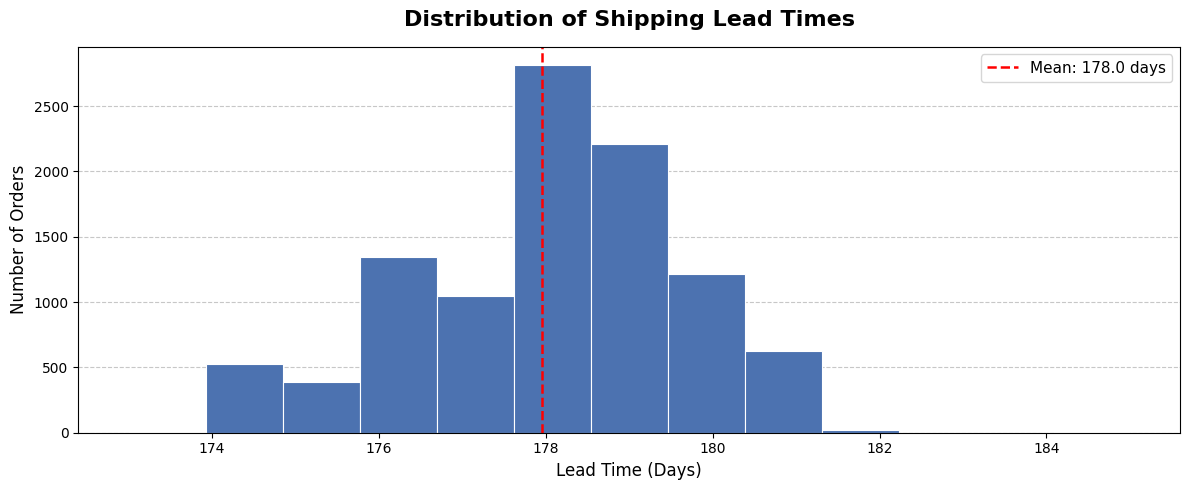

✅ Chart 1 saved!


In [19]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df['Lead Time (Days)'], bins=13, color='#4C72B0', edgecolor='white', linewidth=0.8)

ax.set_title('Distribution of Shipping Lead Times', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Lead Time (Days)', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)

# Add mean line
mean_lt = df['Lead Time (Days)'].mean()
ax.axvline(mean_lt, color='red', linestyle='--', linewidth=1.8, label=f'Mean: {mean_lt:.1f} days')
ax.legend(fontsize=11)

# Add grid
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart1_leadtime_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 1 saved!")

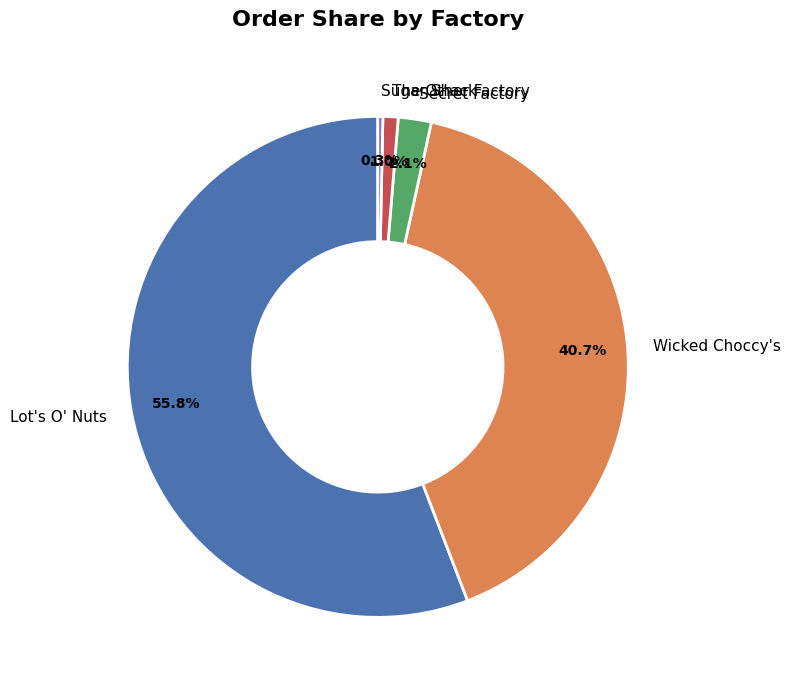

✅ Chart 2 saved!


In [20]:
factory_counts = df['Factory'].value_counts()

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(9, 7))

wedges, texts, autotexts = ax.pie(
    factory_counts.values,
    labels=factory_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)

for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

ax.set_title('Order Share by Factory', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('chart2_orders_by_factory.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 2 saved!")

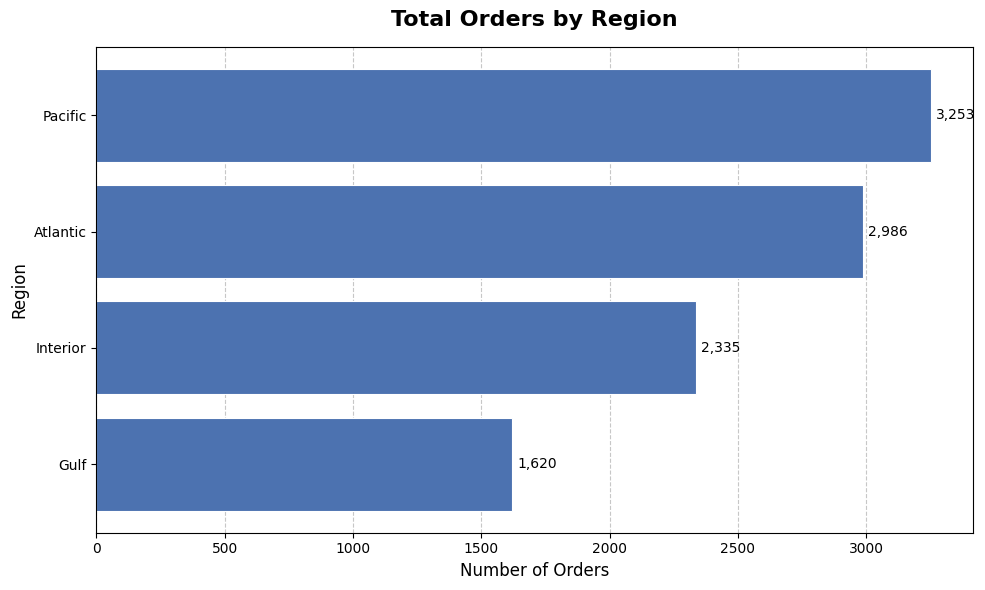

✅ Chart 3 saved!


In [23]:
region_counts = df['Region'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(region_counts.index, region_counts.values,
               color='#4C72B0', edgecolor='white', linewidth=0.8)

# Add value labels
for bar, val in zip(bars, region_counts.values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_title('Total Orders by Region', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Number of Orders', fontsize=12)
ax.set_ylabel('Region', fontsize=12)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart3_orders_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 3 saved!")

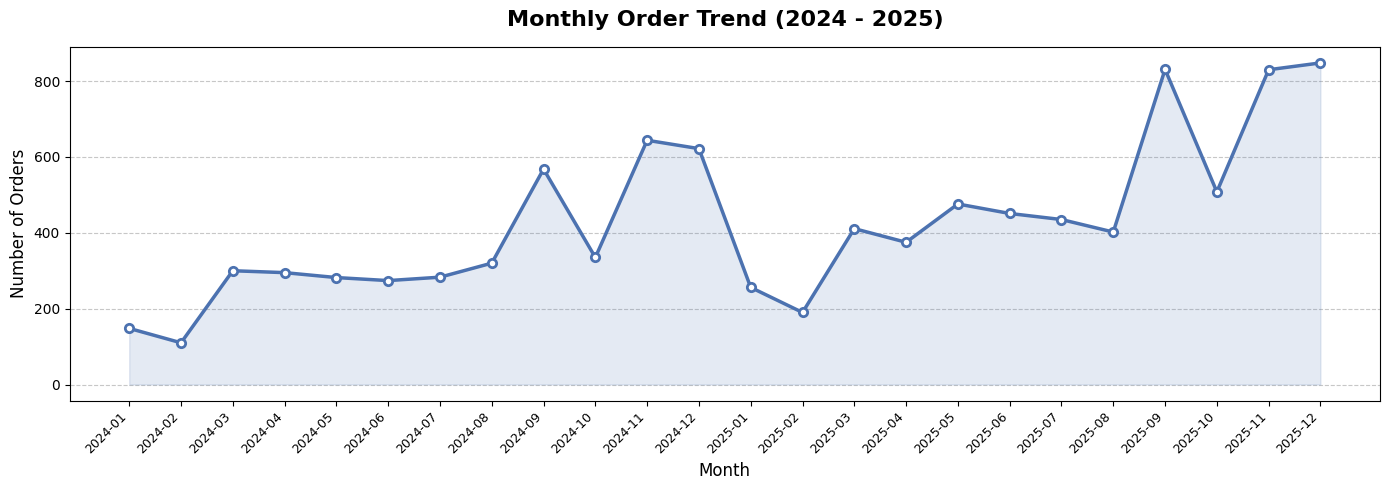

✅ Chart 4 saved!


In [24]:
# Extract month-year from Order Date
df['Month-Year'] = df['Order Date'].dt.to_period('M')
monthly_orders = df.groupby('Month-Year').size().reset_index(name='Order Count')
monthly_orders['Month-Year-Str'] = monthly_orders['Month-Year'].astype(str)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly_orders['Month-Year-Str'], monthly_orders['Order Count'],
        color='#4C72B0', linewidth=2.5, marker='o', markersize=6, markerfacecolor='white',
        markeredgewidth=2)

# Shade area under line
ax.fill_between(monthly_orders['Month-Year-Str'], monthly_orders['Order Count'],
                alpha=0.15, color='#4C72B0')

# Rotate x labels
plt.xticks(rotation=45, ha='right', fontsize=9)

ax.set_title('Monthly Order Trend (2024 - 2025)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart4_monthly_order_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 4 saved!")

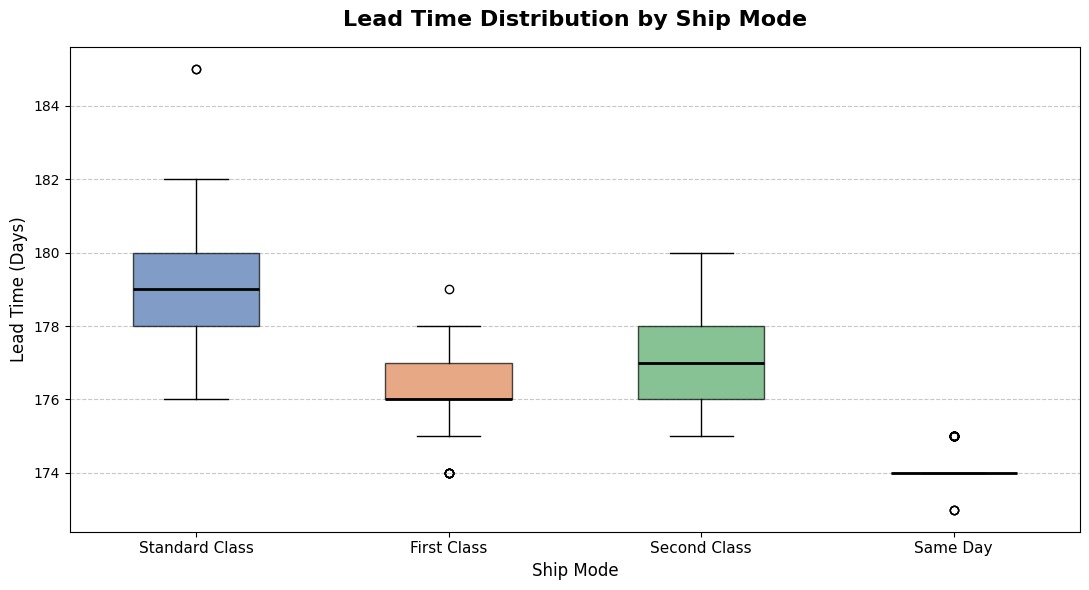

✅ Chart 5 saved!


In [26]:
ship_modes = df['Ship Mode'].unique()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(11, 6))

data_to_plot = [df[df['Ship Mode'] == mode]['Lead Time (Days)'].values 
                for mode in ship_modes]

bp = ax.boxplot(data_to_plot,
                patch_artist=True,
                notch=False,
                vert=True,
                widths=0.5)

# Color each box
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

ax.set_xticklabels(ship_modes, fontsize=11)
ax.set_title('Lead Time Distribution by Ship Mode', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Ship Mode', fontsize=12)
ax.set_ylabel('Lead Time (Days)', fontsize=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart5_leadtime_by_shipmode.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 5 saved!")

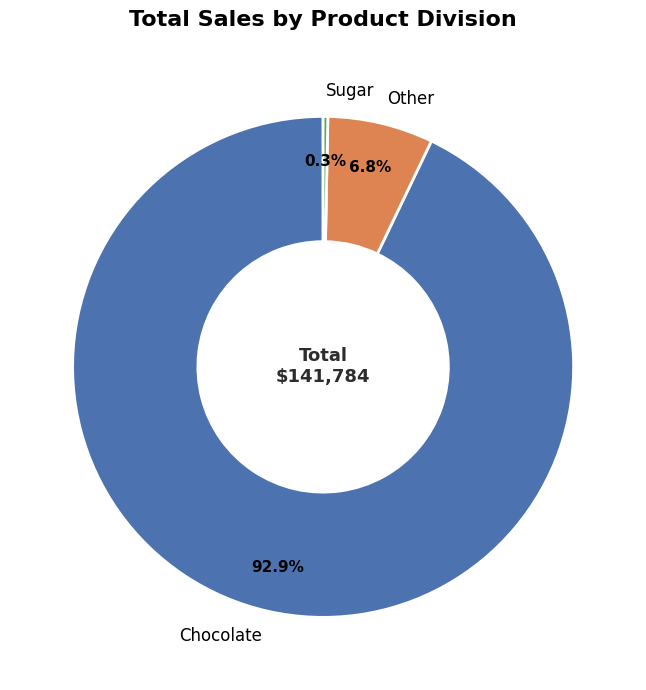

✅ Chart 6 saved!


In [28]:
division_sales = df.groupby('Division')['Sales'].sum().sort_values(ascending=False)

colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(9, 7))

wedges, texts, autotexts = ax.pie(
    division_sales.values,
    labels=division_sales.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)

for text in texts:
    text.set_fontsize(12)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

# Add total in center
total = division_sales.sum()
ax.text(0, 0, f'Total\n${total:,.0f}', ha='center', va='center',
        fontsize=13, fontweight='bold', color='#2d2d2d')

ax.set_title('Total Sales by Product Division', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('chart6_sales_by_division.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 6 saved!")

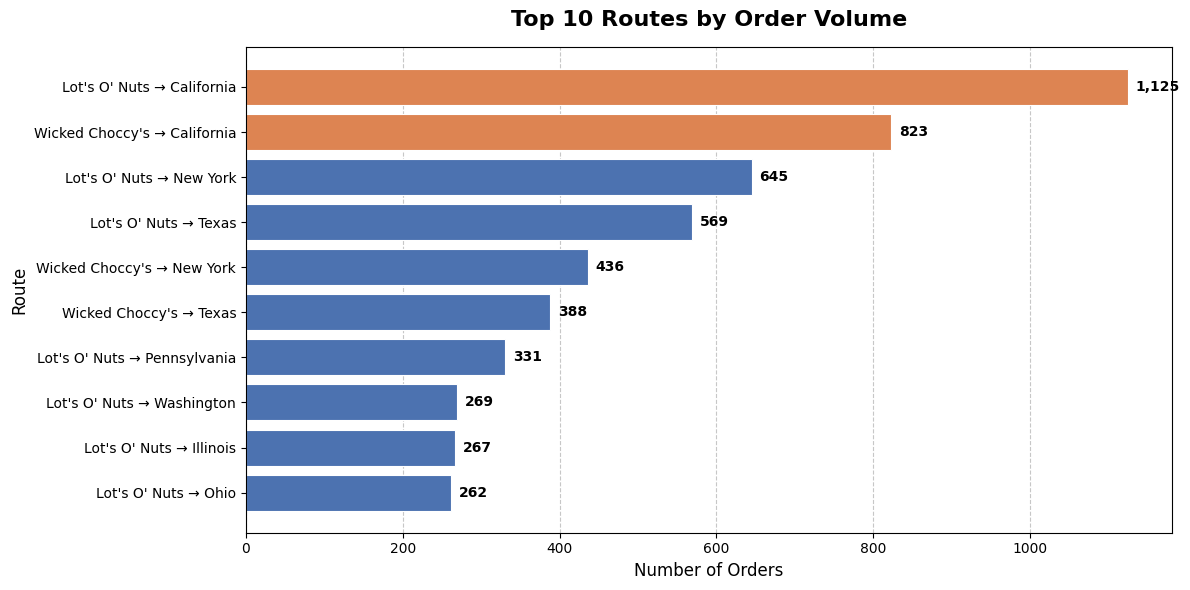

✅ Chart 7 saved!


In [29]:
top10_routes = df['Route (State)'].value_counts().head(10).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#4C72B0'] * 10
colors[-1] = '#DD8452'  # Highlight top route in different color
colors[-2] = '#DD8452'

bars = ax.barh(top10_routes.index, top10_routes.values,
               color=colors, edgecolor='white', linewidth=0.8)

# Add value labels
for bar, val in zip(bars, top10_routes.values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 10 Routes by Order Volume', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Number of Orders', fontsize=12)
ax.set_ylabel('Route', fontsize=12)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart7_top10_routes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 7 saved!")

In [34]:
state_orders = df.groupby('State/Province').size().reset_index(name='Order Count')

fig = px.choropleth(
    state_orders,
    locations='State/Province',
    locationmode='USA-states',
    color='Order Count',
    scope='usa',
    color_continuous_scale='Blues',
    title='Shipment Volume by US State',
    labels={'Order Count': 'Total Orders'}
)

fig.update_layout(
    title_font_size=18,
    title_x=0.5,
    geo=dict(showlakes=True, lakecolor='rgb(255,255,255)'),
    coloraxis_colorbar=dict(title='Orders'),
    margin=dict(l=0, r=0, t=50, b=0)
)

# Save as HTML only — no fig.show()
fig.write_html('chart8_shipment_map.html')
print("✅ Chart 8 saved!")
print("📌 To view the map:")
print("   Go to your project folder and open 'chart8_shipment_map.html' in Chrome or Edge")

✅ Chart 8 saved!
📌 To view the map:
   Go to your project folder and open 'chart8_shipment_map.html' in Chrome or Edge


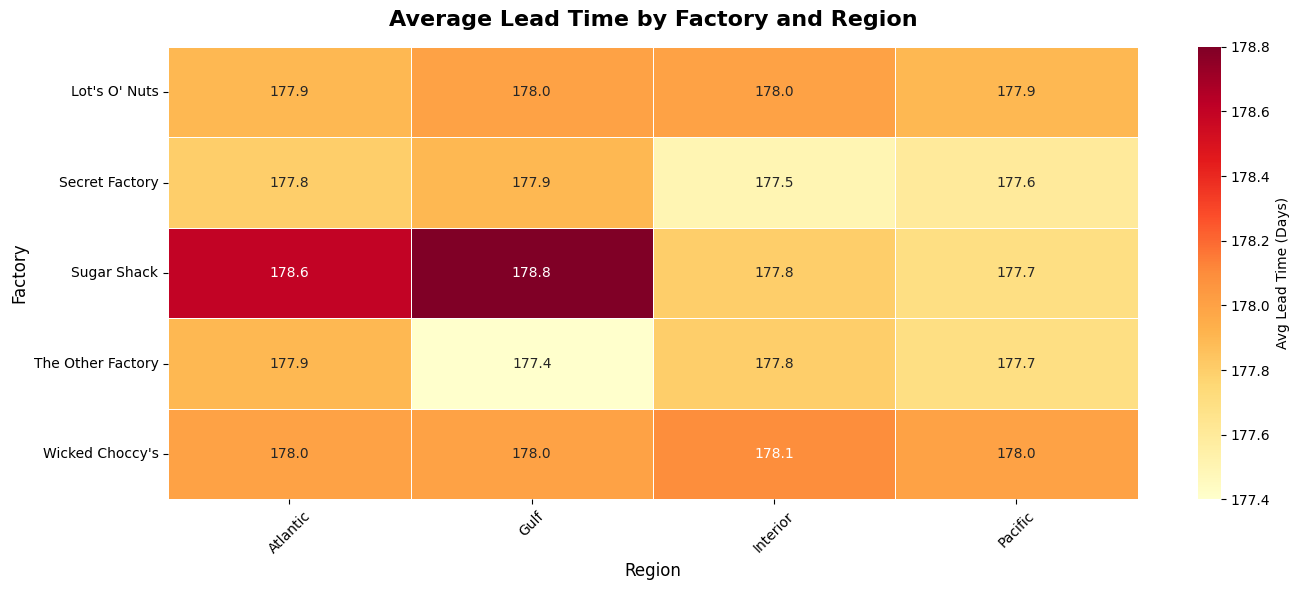

✅ Chart 9 saved!


In [36]:
# Create pivot table
pivot = df.groupby(['Factory', 'Region'])['Lead Time (Days)'].mean().unstack()
pivot = pivot.round(1)

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(pivot,
            annot=True,
            fmt='.1f',
            cmap='YlOrRd',
            linewidths=0.5,
            linecolor='white',
            ax=ax,
            cbar_kws={'label': 'Avg Lead Time (Days)'})

ax.set_title('Average Lead Time by Factory and Region', fontsize=16,
             fontweight='bold', pad=15)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Factory', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('chart9_factory_region_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 9 saved!")

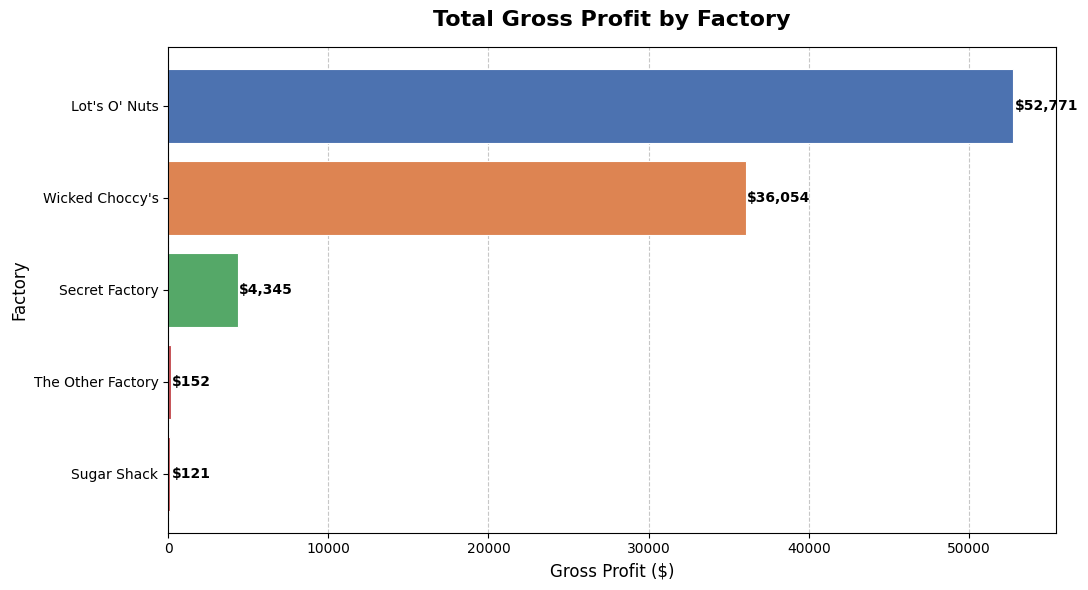

✅ Chart 10 saved!


In [38]:
factory_profit = df.groupby('Factory')['Gross Profit'].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))

colors = ['#C44E52', '#C44E52', '#55A868', '#DD8452', '#4C72B0']

bars = ax.barh(factory_profit.index, factory_profit.values,
               color=colors, edgecolor='white', linewidth=0.8)

# Add value labels
for bar, val in zip(bars, factory_profit.values):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Total Gross Profit by Factory', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Gross Profit ($)', fontsize=12)
ax.set_ylabel('Factory', fontsize=12)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart10_profit_by_factory.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 10 saved!")

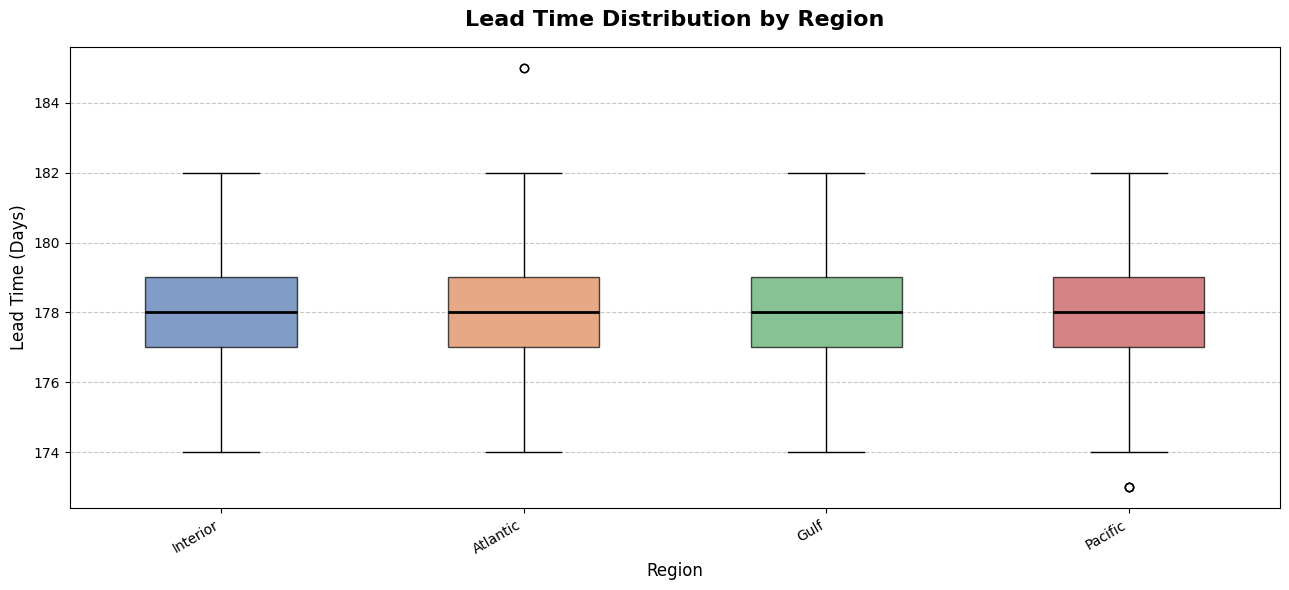

✅ Chart 11 saved!


In [40]:
regions = df['Region'].unique()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52',
          '#8172B2', '#937860', '#DA8BC3', '#8C8C8C']

fig, ax = plt.subplots(figsize=(13, 6))

data_to_plot = [df[df['Region'] == region]['Lead Time (Days)'].values
                for region in regions]

bp = ax.boxplot(data_to_plot,
                patch_artist=True,
                notch=False,
                vert=True,
                widths=0.5)

# Color boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)

ax.set_xticklabels(regions, fontsize=10, rotation=30, ha='right')
ax.set_title('Lead Time Distribution by Region', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Region', fontsize=12)
ax.set_ylabel('Lead Time (Days)', fontsize=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart11_leadtime_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 11 saved!")

In [42]:
route_summary = df.groupby('Route (State)').agg(
    Total_Orders    = ('Order ID', 'count'),
    Avg_Lead_Time   = ('Lead Time (Days)', 'mean'),
    Min_Lead_Time   = ('Lead Time (Days)', 'min'),
    Max_Lead_Time   = ('Lead Time (Days)', 'max'),
    Std_Lead_Time   = ('Lead Time (Days)', 'std'),
    Total_Sales     = ('Sales', 'sum'),
    Total_Profit    = ('Gross Profit', 'sum')
).reset_index()

# Round for clarity
route_summary['Avg_Lead_Time'] = route_summary['Avg_Lead_Time'].round(2)
route_summary['Std_Lead_Time'] = route_summary['Std_Lead_Time'].round(2)
route_summary['Total_Sales']   = route_summary['Total_Sales'].round(2)
route_summary['Total_Profit']  = route_summary['Total_Profit'].round(2)

print("✅ Route Summary Table created!")
print(f"📊 Total Routes Analysed : {len(route_summary)}")
print(f"\nSample Route Summary:")
print(route_summary.head(10).to_string(index=False))

✅ Route Summary Table created!
📊 Total Routes Analysed : 196

Sample Route Summary:
                       Route (State)  Total_Orders  Avg_Lead_Time  Min_Lead_Time  Max_Lead_Time  Std_Lead_Time  Total_Sales  Total_Profit
             Lot's O' Nuts → Alabama            34         178.47            176            181           1.54       475.61        326.91
             Lot's O' Nuts → Alberta            16         178.62            178            179           0.50       204.32        141.42
             Lot's O' Nuts → Arizona           111         178.03            174            181           1.98      1468.05       1013.15
            Lot's O' Nuts → Arkansas            31         178.29            174            181           2.22       434.69        299.69
    Lot's O' Nuts → British Columbia            18         178.44            176            179           0.98       253.40        173.80
          Lot's O' Nuts → California          1125         177.78            173        

In [48]:
# Fill NaN std values with 0
route_summary['Std_Lead_Time'] = route_summary['Std_Lead_Time'].fillna(0)

# Filter routes with minimum 10 orders for credibility
route_summary_filtered = route_summary[route_summary['Total_Orders'] >= 10].copy()

print(f"Total routes before filter : {len(route_summary)}")
print(f"Total routes after filter  : {len(route_summary_filtered)} (min 10 orders)")

# Normalize Avg Lead Time (lower is better)
route_summary_filtered['LT_Normalized'] = (
    route_summary_filtered['Avg_Lead_Time'] - route_summary_filtered['Avg_Lead_Time'].min()
) / (
    route_summary_filtered['Avg_Lead_Time'].max() - route_summary_filtered['Avg_Lead_Time'].min()
)

# Normalize Std Lead Time (lower is better)
route_summary_filtered['Std_Normalized'] = (
    route_summary_filtered['Std_Lead_Time'] - route_summary_filtered['Std_Lead_Time'].min()
) / (
    route_summary_filtered['Std_Lead_Time'].max() - route_summary_filtered['Std_Lead_Time'].min()
)

# Efficiency Score
route_summary_filtered['Efficiency_Score'] = (
    1 - (0.7 * route_summary_filtered['LT_Normalized'] +
         0.3 * route_summary_filtered['Std_Normalized'])
) * 100

route_summary_filtered['Efficiency_Score'] = route_summary_filtered['Efficiency_Score'].round(2)

# Rank routes
route_summary_filtered['Rank'] = route_summary_filtered['Efficiency_Score'].rank(
    ascending=False, method='dense').astype('Int64')

route_summary_filtered = route_summary_filtered.sort_values('Rank')

print(f"\n✅ Efficiency Scores calculated!")
print(f"\nTop 10 Most Efficient Routes (min 10 orders):")
print(route_summary_filtered[['Route (State)', 'Avg_Lead_Time', 'Std_Lead_Time',
                      'Total_Orders', 'Efficiency_Score', 'Rank']].head(10).to_string(index=False))

print(f"\nBottom 10 Least Efficient Routes (min 10 orders):")
print(route_summary_filtered[['Route (State)', 'Avg_Lead_Time', 'Std_Lead_Time',
                      'Total_Orders', 'Efficiency_Score', 'Rank']].tail(10).to_string(index=False))

Total routes before filter : 196
Total routes after filter  : 96 (min 10 orders)

✅ Efficiency Scores calculated!

Top 10 Most Efficient Routes (min 10 orders):
                Route (State)  Avg_Lead_Time  Std_Lead_Time  Total_Orders  Efficiency_Score  Rank
  Wicked Choccy's → Louisiana         176.87           1.51            15             82.78     1
      Lot's O' Nuts → Ontario         177.14           1.27            28             77.23     2
    Secret Factory → Illinois         177.00           1.68            13             75.24     3
   Wicked Choccy's → Manitoba         177.60           0.84            10             68.13     4
Lot's O' Nuts → New Hampshire         177.31           1.49            13             67.41     5
    Lot's O' Nuts → Louisiana         177.21           1.79            24             65.87     6
 Lot's O' Nuts → Rhode Island         177.20           1.88            30             64.69     7
     Lot's O' Nuts → Nebraska         177.35           

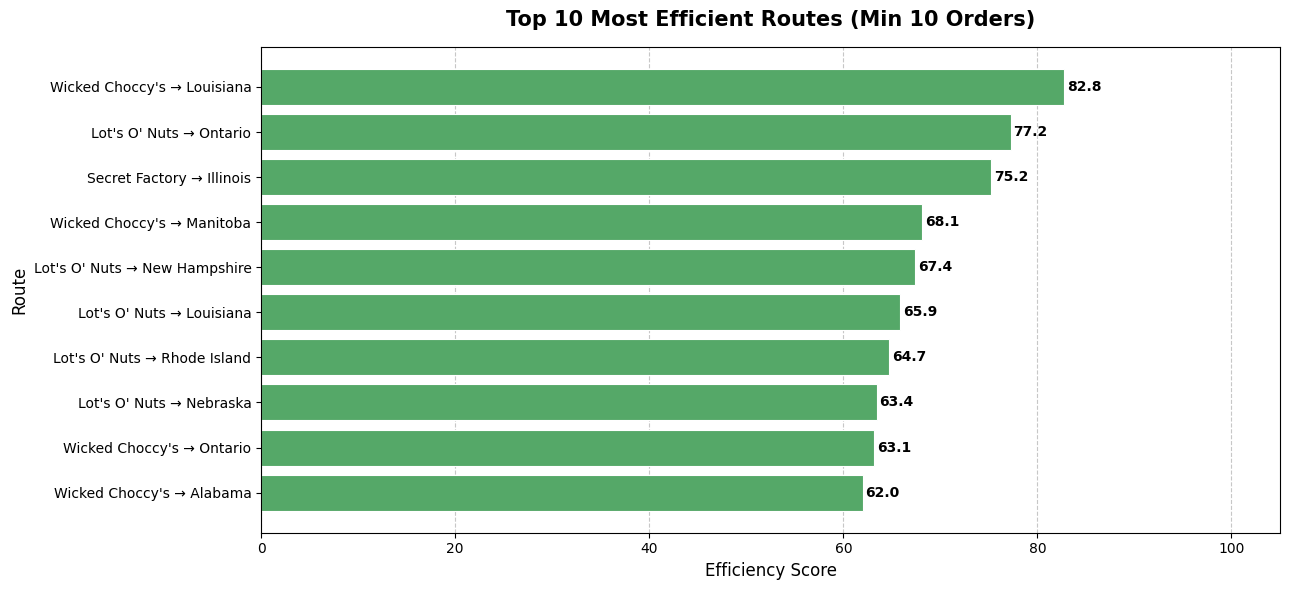

✅ Chart 12 saved!


In [50]:
top10 = route_summary_filtered.head(10).sort_values('Efficiency_Score', ascending=True)

fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.barh(top10['Route (State)'], top10['Efficiency_Score'],
               color='#55A868', edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, top10['Efficiency_Score']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 10 Most Efficient Routes (Min 10 Orders)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Efficiency Score', fontsize=12)
ax.set_ylabel('Route', fontsize=12)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.set_xlim(0, 105)

plt.tight_layout()
plt.savefig('chart12_top10_efficient_routes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 12 saved!")

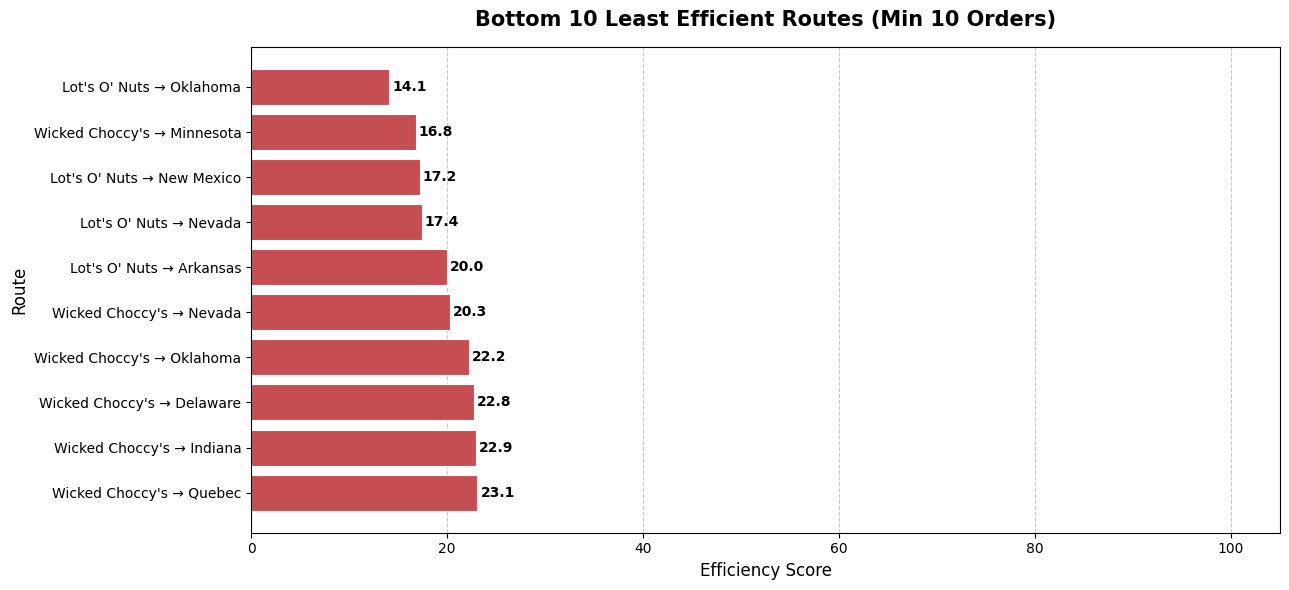

✅ Chart 13 saved!


In [52]:
bottom10 = route_summary_filtered.tail(10).sort_values('Efficiency_Score', ascending=False)

fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.barh(bottom10['Route (State)'], bottom10['Efficiency_Score'],
               color='#C44E52', edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, bottom10['Efficiency_Score']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Bottom 10 Least Efficient Routes (Min 10 Orders)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Efficiency Score', fontsize=12)
ax.set_ylabel('Route', fontsize=12)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.set_xlim(0, 105)

plt.tight_layout()
plt.savefig('chart13_bottom10_inefficient_routes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 13 saved!")

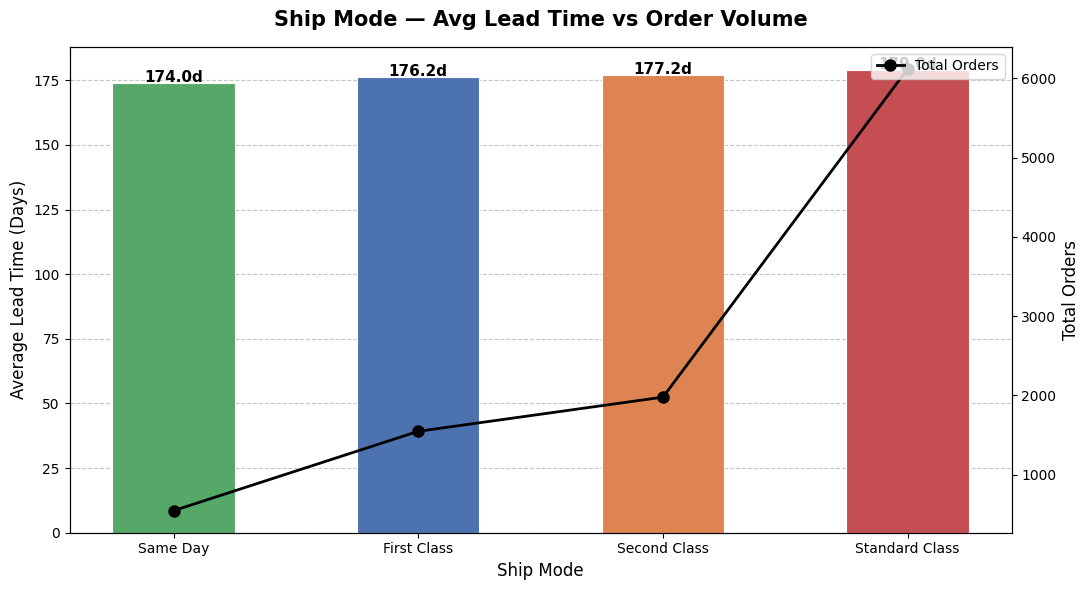

✅ Chart 14 saved!


In [54]:
shipmode_summary = df.groupby('Ship Mode').agg(
    Avg_Lead_Time = ('Lead Time (Days)', 'mean'),
    Total_Orders  = ('Order ID', 'count'),
    Total_Sales   = ('Sales', 'sum')
).reset_index().sort_values('Avg_Lead_Time')

fig, ax1 = plt.subplots(figsize=(11, 6))

colors = ['#55A868', '#4C72B0', '#DD8452', '#C44E52']
bars = ax1.bar(shipmode_summary['Ship Mode'],
               shipmode_summary['Avg_Lead_Time'],
               color=colors, edgecolor='white',
               linewidth=0.8, width=0.5)

for bar, val in zip(bars, shipmode_summary['Avg_Lead_Time']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}d', ha='center', fontsize=11, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(shipmode_summary['Ship Mode'],
         shipmode_summary['Total_Orders'],
         color='black', marker='o', linewidth=2,
         markersize=8, label='Total Orders')
ax2.set_ylabel('Total Orders', fontsize=12)

ax1.set_title('Ship Mode — Avg Lead Time vs Order Volume',
              fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel('Ship Mode', fontsize=12)
ax1.set_ylabel('Average Lead Time (Days)', fontsize=12)
ax1.yaxis.grid(True, linestyle='--', alpha=0.7)
ax1.set_axisbelow(True)
ax2.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('chart14_shipmode_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 14 saved!")

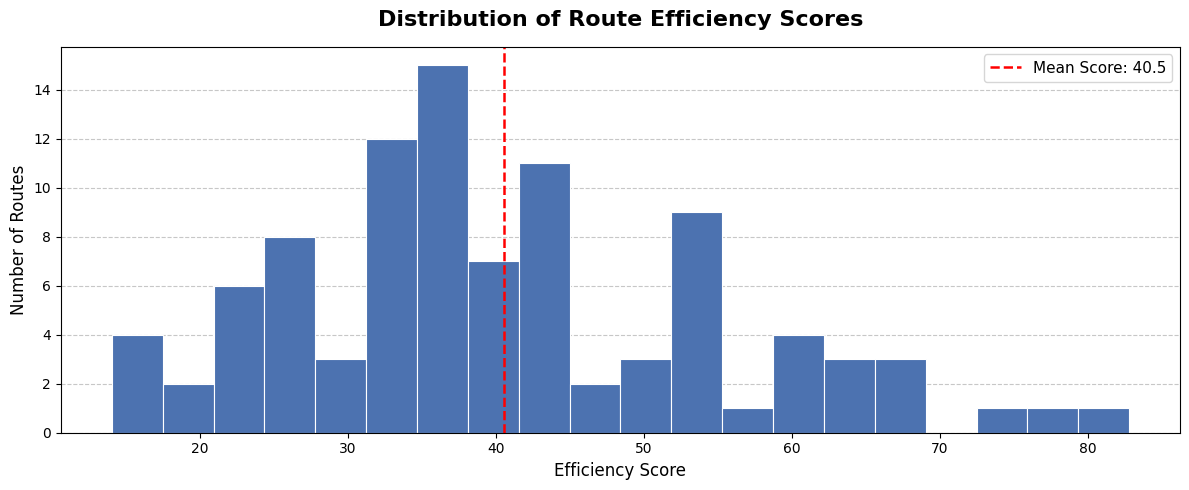

✅ Chart 15 saved!


In [56]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(route_summary_filtered['Efficiency_Score'], bins=20,
        color='#4C72B0', edgecolor='white', linewidth=0.8)

mean_score = route_summary_filtered['Efficiency_Score'].mean()
ax.axvline(mean_score, color='red', linestyle='--',
           linewidth=1.8, label=f'Mean Score: {mean_score:.1f}')

ax.set_title('Distribution of Route Efficiency Scores', fontsize=16,
             fontweight='bold', pad=15)
ax.set_xlabel('Efficiency Score', fontsize=12)
ax.set_ylabel('Number of Routes', fontsize=12)
ax.legend(fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart15_efficiency_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 15 saved!")

In [58]:
state_summary = df.groupby('State/Province').agg(
    Total_Orders  = ('Order ID', 'count'),
    Avg_Lead_Time = ('Lead Time (Days)', 'mean'),
    Total_Sales   = ('Sales', 'sum'),
    Total_Profit  = ('Gross Profit', 'sum')
).reset_index()

state_summary['Avg_Lead_Time'] = state_summary['Avg_Lead_Time'].round(2)
state_summary['Total_Sales']   = state_summary['Total_Sales'].round(2)
state_summary['Total_Profit']  = state_summary['Total_Profit'].round(2)

# Classify states as Fast, Average or Slow
mean_lt = state_summary['Avg_Lead_Time'].mean()
std_lt  = state_summary['Avg_Lead_Time'].std()

def classify_state(lt):
    if lt <= mean_lt - 0.5 * std_lt:
        return 'Fast'
    elif lt >= mean_lt + 0.5 * std_lt:
        return 'Slow'
    else:
        return 'Average'

state_summary['Performance'] = state_summary['Avg_Lead_Time'].apply(classify_state)

print("✅ State Summary created!")
print(f"\nTotal States Analysed : {len(state_summary)}")
print(f"\nPerformance Breakdown:")
print(state_summary['Performance'].value_counts())
print(f"\nTop 10 Slowest States:")
print(state_summary.nlargest(10, 'Avg_Lead_Time')[
    ['State/Province', 'Avg_Lead_Time', 'Total_Orders', 'Performance']
].to_string(index=False))
print(f"\nTop 10 Fastest States:")
print(state_summary.nsmallest(10, 'Avg_Lead_Time')[
    ['State/Province', 'Avg_Lead_Time', 'Total_Orders', 'Performance']
].to_string(index=False))

✅ State Summary created!

Total States Analysed : 59

Performance Breakdown:
Performance
Average    33
Fast       15
Slow       11
Name: count, dtype: int64

Top 10 Slowest States:
           State/Province  Avg_Lead_Time  Total_Orders Performance
Newfoundland and Labrador         181.67             6        Slow
     District of Columbia         179.50            10        Slow
                    Maine         179.00             8        Slow
             Saskatchewan         179.00             2        Slow
                  Wyoming         179.00             1        Slow
     Prince Edward Island         178.80            10        Slow
                  Alberta         178.77            26        Slow
             South Dakota         178.58            12        Slow
               New Mexico         178.54            37        Slow
                Minnesota         178.53            89        Slow

Top 10 Fastest States:
State/Province  Avg_Lead_Time  Total_Orders Performance
  

In [60]:
# US state abbreviation mapping
state_abbrev = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR',
    'California': 'CA', 'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE',
    'Florida': 'FL', 'Georgia': 'GA', 'Hawaii': 'HI', 'Idaho': 'ID',
    'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA', 'Kansas': 'KS',
    'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New Mexico': 'NM', 'New York': 'NY',
    'North Carolina': 'NC', 'North Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK',
    'Oregon': 'OR', 'Pennsylvania': 'PA', 'Rhode Island': 'RI', 'South Carolina': 'SC',
    'South Dakota': 'SD', 'Tennessee': 'TN', 'Texas': 'TX', 'Utah': 'UT',
    'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA', 'West Virginia': 'WV',
    'Wisconsin': 'WI', 'Wyoming': 'WY', 'District of Columbia': 'DC',
    # Canadian Provinces
    'Ontario': 'ON', 'Quebec': 'QC', 'British Columbia': 'BC',
    'Alberta': 'AB', 'Manitoba': 'MB', 'Saskatchewan': 'SK'
}

state_summary['State_Code'] = state_summary['State/Province'].map(state_abbrev)

# Filter US states only for map
us_states = state_summary[state_summary['State_Code'].str.len() == 2].copy()
us_states = us_states[~us_states['State_Code'].isin(['ON', 'QC', 'BC', 'AB', 'MB', 'SK'])]

fig = px.choropleth(
    us_states,
    locations='State_Code',
    locationmode='USA-states',
    color='Avg_Lead_Time',
    scope='usa',
    color_continuous_scale='RdYlGn_r',
    title='Average Shipping Lead Time by US State',
    labels={'Avg_Lead_Time': 'Avg Lead Time (Days)'},
    hover_name='State/Province',
    hover_data={'Total_Orders': True, 'Avg_Lead_Time': ':.2f'}
)

fig.update_layout(
    title_font_size=18,
    title_x=0.5,
    geo=dict(showlakes=True, lakecolor='rgb(255,255,255)'),
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.write_html('chart16_leadtime_by_state_map.html')
print("✅ Chart 16 saved!")
print("📌 Open 'chart16_leadtime_by_state_map.html' in your browser to view the map!")

✅ Chart 16 saved!
📌 Open 'chart16_leadtime_by_state_map.html' in your browser to view the map!


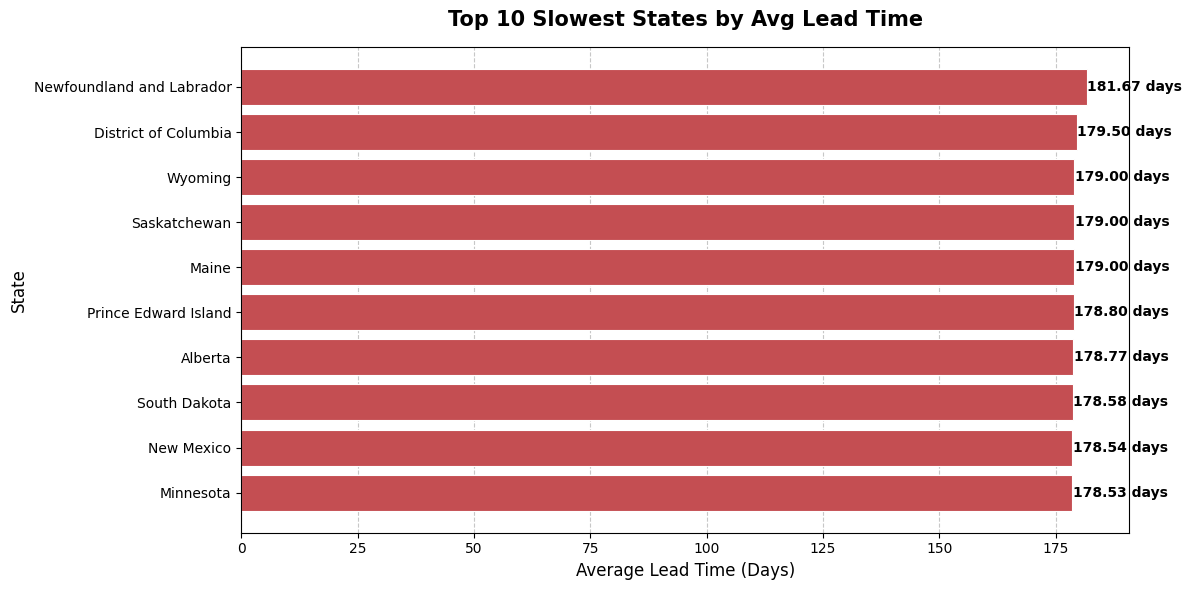

✅ Chart 17 saved!


In [70]:
slowest_states = state_summary.nlargest(10, 'Avg_Lead_Time').sort_values(
    'Avg_Lead_Time', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(slowest_states['State/Province'],
               slowest_states['Avg_Lead_Time'],
               color='#C44E52', edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, slowest_states['Avg_Lead_Time']):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f} days', va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 10 Slowest States by Avg Lead Time',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Average Lead Time (Days)', fontsize=12)
ax.set_ylabel('State', fontsize=12)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart17_slowest_states.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 17 saved!")

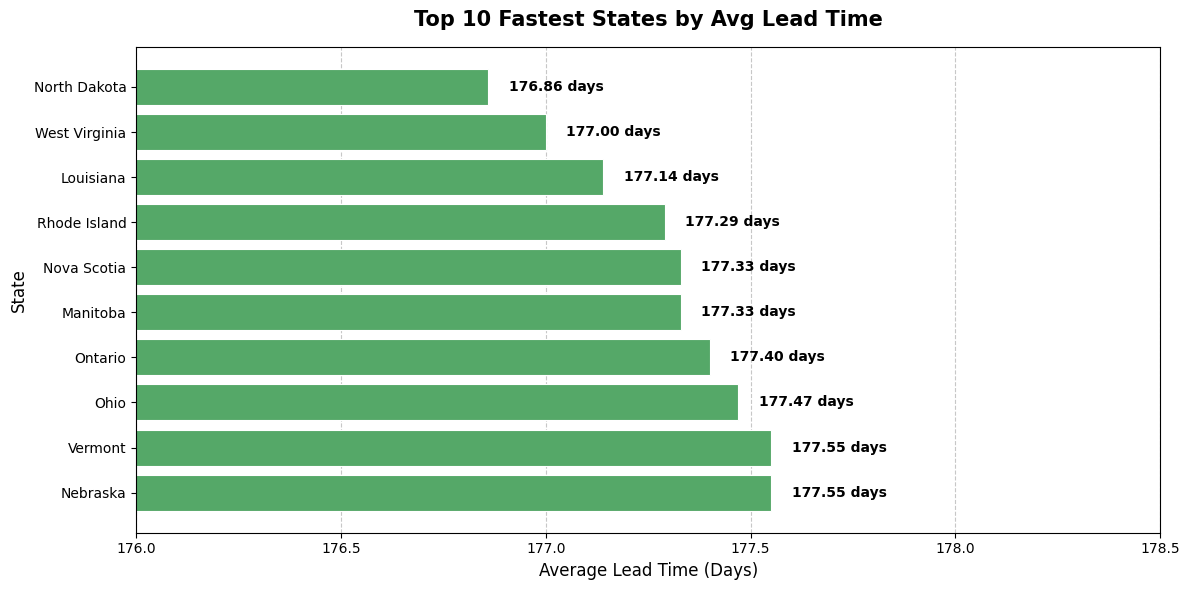

✅ Chart 18 saved!


In [66]:
fastest_states = state_summary.nsmallest(10, 'Avg_Lead_Time').sort_values(
    'Avg_Lead_Time', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(fastest_states['State/Province'],
               fastest_states['Avg_Lead_Time'],
               color='#55A868', edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, fastest_states['Avg_Lead_Time']):
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height()/2,
            f'{val:.2f} days', va='center', fontsize=10, fontweight='bold')

ax.set_title('Top 10 Fastest States by Avg Lead Time',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Average Lead Time (Days)', fontsize=12)
ax.set_ylabel('State', fontsize=12)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

ax.set_xlim(176, 178.5)
plt.tight_layout()
plt.savefig('chart18_fastest_states.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 18 saved!")

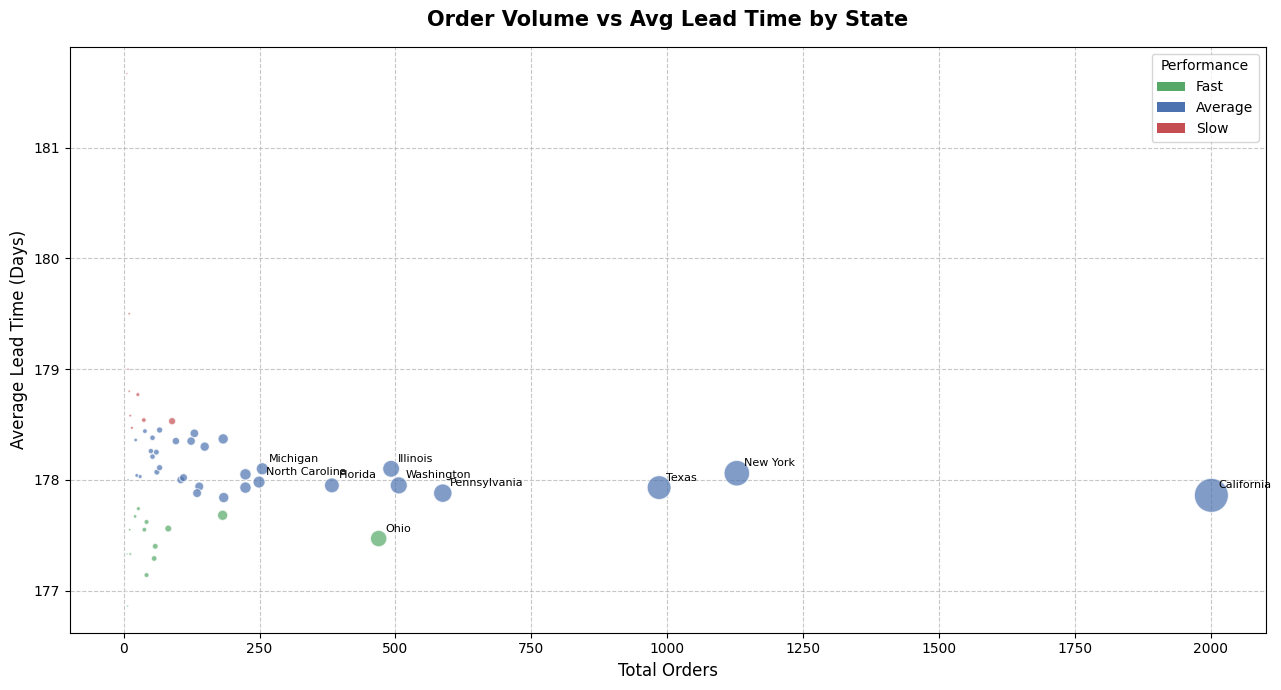

✅ Chart 19 saved!


In [72]:
fig, ax = plt.subplots(figsize=(13, 7))

# Color by performance
color_map = {'Fast': '#55A868', 'Average': '#4C72B0', 'Slow': '#C44E52'}
colors = state_summary['Performance'].map(color_map)

scatter = ax.scatter(state_summary['Total_Orders'],
                     state_summary['Avg_Lead_Time'],
                     c=colors,
                     s=state_summary['Total_Orders'] * 0.3,
                     alpha=0.7,
                     edgecolors='white',
                     linewidth=0.8)

# Label top states
top_states = state_summary.nlargest(10, 'Total_Orders')
for _, row in top_states.iterrows():
    ax.annotate(row['State/Province'],
                (row['Total_Orders'], row['Avg_Lead_Time']),
                fontsize=8, ha='left',
                xytext=(5, 5), textcoords='offset points')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#55A868', label='Fast'),
    Patch(facecolor='#4C72B0', label='Average'),
    Patch(facecolor='#C44E52', label='Slow')
]
ax.legend(handles=legend_elements, fontsize=10, title='Performance')

ax.set_title('Order Volume vs Avg Lead Time by State',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Total Orders', fontsize=12)
ax.set_ylabel('Average Lead Time (Days)', fontsize=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart19_volume_vs_leadtime_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 19 saved!")

In [74]:
# Define delay threshold as 75th percentile
delay_threshold = df['Lead Time (Days)'].quantile(0.75)
print(f"📊 Delay Threshold (75th percentile) : {delay_threshold} days")

# Flag delayed orders
df['Is_Delayed'] = df['Lead Time (Days)'] > delay_threshold

total_orders   = len(df)
delayed_orders = df['Is_Delayed'].sum()

print(f"\n📦 Total Orders   : {total_orders:,}")
print(f"⚠️  Delayed Orders : {delayed_orders:,}")
print(f"📈 Delay Rate     : {(delayed_orders/total_orders*100):.2f}%")
print(f"\nDelay breakdown by Ship Mode:")
print(df.groupby('Ship Mode')['Is_Delayed'].agg(['sum', 'mean']).rename(
    columns={'sum': 'Delayed Orders', 'mean': 'Delay Rate'}
).assign(**{'Delay Rate': lambda x: (x['Delay Rate']*100).round(2)}
).to_string())

📊 Delay Threshold (75th percentile) : 179.0 days

📦 Total Orders   : 10,194
⚠️  Delayed Orders : 1,864
📈 Delay Rate     : 18.29%

Delay breakdown by Ship Mode:
                Delayed Orders  Delay Rate
Ship Mode                                 
First Class                  0        0.00
Same Day                     0        0.00
Second Class                 7        0.35
Standard Class            1857       30.34


In [76]:
route_delay = df.groupby('Route (State)').agg(
    Total_Orders   = ('Order ID', 'count'),
    Delayed_Orders = ('Is_Delayed', 'sum'),
).reset_index()

route_delay['Delay_Rate_%'] = (
    route_delay['Delayed_Orders'] / route_delay['Total_Orders'] * 100
).round(2)

# Filter min 10 orders for credibility
route_delay_filtered = route_delay[route_delay['Total_Orders'] >= 10].copy()
route_delay_filtered = route_delay_filtered.sort_values('Delay_Rate_%', ascending=False)

print("✅ Route Delay Frequency calculated!")
print(f"\nTop 10 Highest Delay Rate Routes:")
print(route_delay_filtered.head(10).to_string(index=False))
print(f"\nTop 10 Lowest Delay Rate Routes:")
print(route_delay_filtered.tail(10).to_string(index=False))

✅ Route Delay Frequency calculated!

Top 10 Highest Delay Rate Routes:
              Route (State)  Total_Orders  Delayed_Orders  Delay_Rate_%
     Lot's O' Nuts → Nevada            24              10         41.67
Wicked Choccy's → Minnesota            45              16         35.56
   Wicked Choccy's → Oregon            43              15         34.88
   Lot's O' Nuts → Oklahoma            41              14         34.15
 Wicked Choccy's → Michigan           100              34         34.00
 Wicked Choccy's → Delaware            49              16         32.65
   Lot's O' Nuts → Arkansas            31              10         32.26
 Wicked Choccy's → Oklahoma            25               8         32.00
     Lot's O' Nuts → Oregon            77              23         29.87
    Lot's O' Nuts → Alabama            34              10         29.41

Top 10 Lowest Delay Rate Routes:
                   Route (State)  Total_Orders  Delayed_Orders  Delay_Rate_%
  Lot's O' Nuts → South Ca

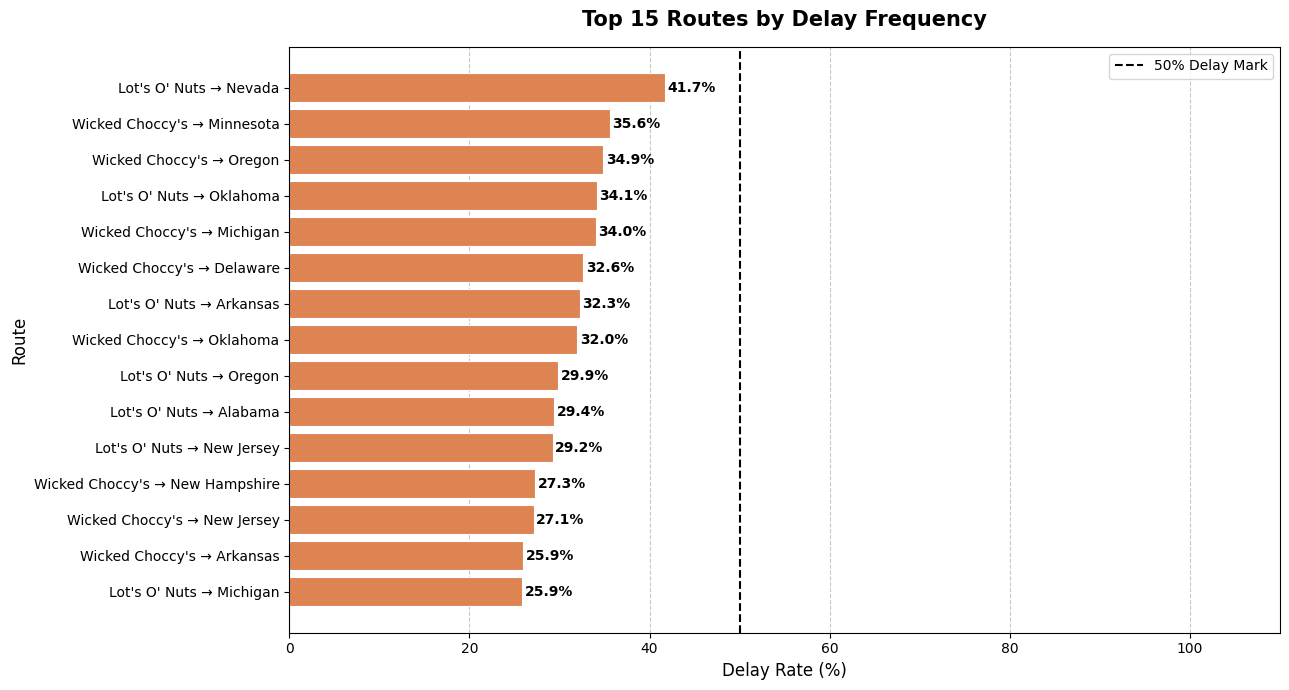

✅ Chart 20 saved!


In [78]:
top15_delayed = route_delay_filtered.head(15).sort_values(
    'Delay_Rate_%', ascending=True)

fig, ax = plt.subplots(figsize=(13, 7))

colors = ['#C44E52' if x >= 50 else '#DD8452'
          for x in top15_delayed['Delay_Rate_%']]

bars = ax.barh(top15_delayed['Route (State)'],
               top15_delayed['Delay_Rate_%'],
               color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, top15_delayed['Delay_Rate_%']):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

# Add 50% reference line
ax.axvline(50, color='black', linestyle='--',
           linewidth=1.5, label='50% Delay Mark')

ax.set_title('Top 15 Routes by Delay Frequency',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Delay Rate (%)', fontsize=12)
ax.set_ylabel('Route', fontsize=12)
ax.legend(fontsize=10)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.set_xlim(0, 110)

plt.tight_layout()
plt.savefig('chart20_delay_rate_by_route.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 20 saved!")

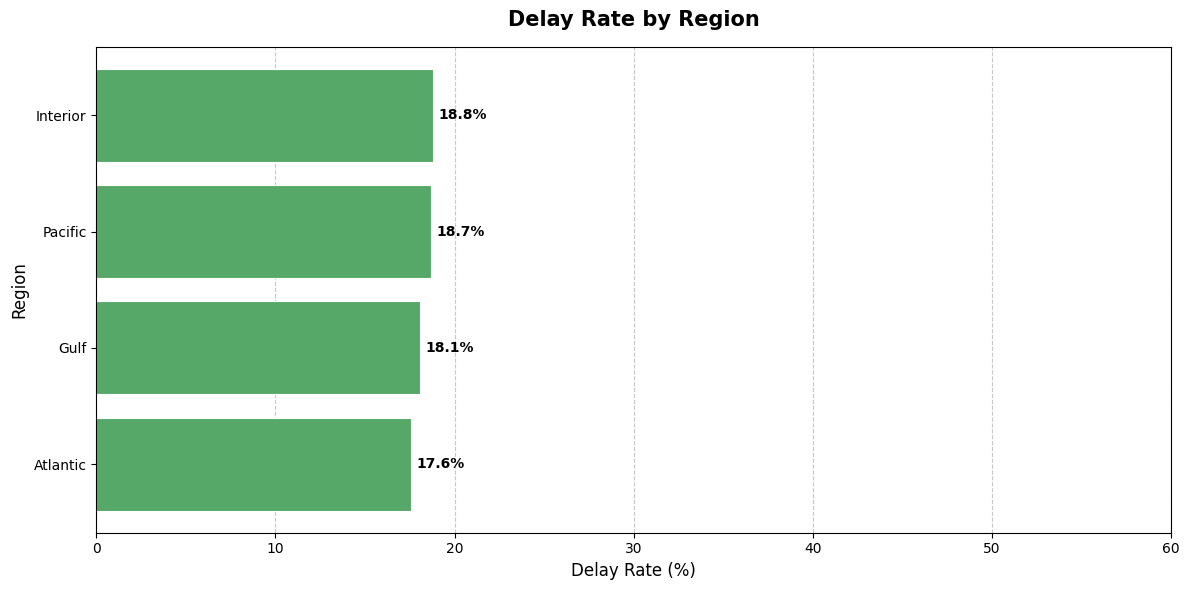

✅ Chart 21 saved!


In [80]:
region_delay = df.groupby('Region').agg(
    Total_Orders   = ('Order ID', 'count'),
    Delayed_Orders = ('Is_Delayed', 'sum'),
).reset_index()

region_delay['Delay_Rate_%'] = (
    region_delay['Delayed_Orders'] / region_delay['Total_Orders'] * 100
).round(2)

region_delay = region_delay.sort_values('Delay_Rate_%', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#55A868' if x < 20 else '#DD8452' if x < 30 else '#C44E52'
          for x in region_delay['Delay_Rate_%']]

bars = ax.barh(region_delay['Region'],
               region_delay['Delay_Rate_%'],
               color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, region_delay['Delay_Rate_%']):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_title('Delay Rate by Region',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Delay Rate (%)', fontsize=12)
ax.set_ylabel('Region', fontsize=12)
ax.xaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)
ax.set_xlim(0, 60)

plt.tight_layout()
plt.savefig('chart21_delay_rate_by_region.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 21 saved!")

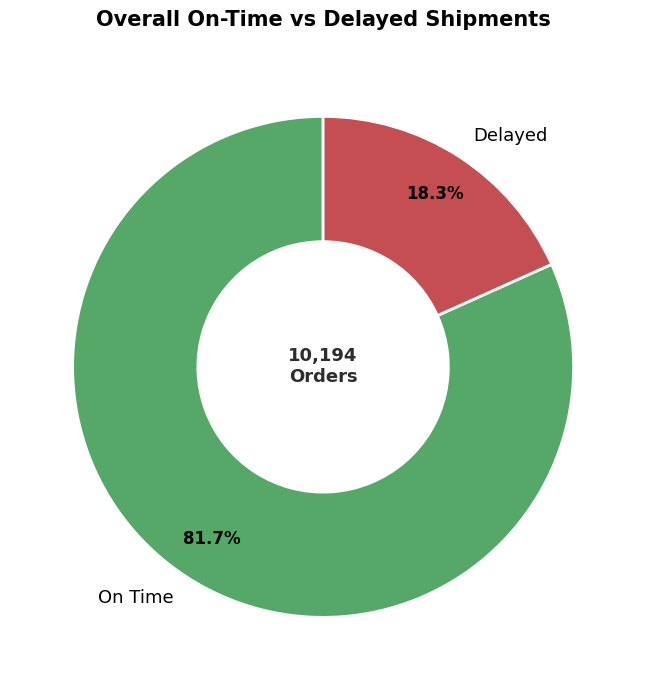

✅ Chart 22 saved!


In [82]:
on_time = total_orders - delayed_orders
labels  = ['On Time', 'Delayed']
values  = [on_time, delayed_orders]
colors  = ['#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(8, 7))

wedges, texts, autotexts = ax.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)

for text in texts:
    text.set_fontsize(13)
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')

ax.text(0, 0, f'{total_orders:,}\nOrders', ha='center', va='center',
        fontsize=13, fontweight='bold', color='#2d2d2d')

ax.set_title('Overall On-Time vs Delayed Shipments',
             fontsize=15, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('chart22_ontime_vs_delayed.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart 22 saved!")

In [84]:
import sys
import os

print("Python executable:")
print(sys.executable)

print("\nCurrent working directory:")
print(os.getcwd())

print("\nVirtual env contents:")
for item in os.listdir():
    print(item)

Python executable:
C:\Users\DIYA\OneDrive\Desktop\projects\Nassau Candy Distributor\supply_chain_env\Scripts\python.exe

Current working directory:
C:\Users\DIYA

Virtual env contents:
.anaconda
.conda
.condarc
.continuum
.idlerc
.ipynb_checkpoints
.ipython
.jupyter
.matplotlib
.streamlit
.VirtualBox
anaconda3
AppData
Application Data
blogs.csv
charts
cleaned_nassau_data.csv
Contacts
Cookies
Customer_Segmentation Proj.ipynb
Customer_Segmentation.ipynb
dataset.zip
dataset_folder
Documents
Downloads
employees.csv
Face Detection.ipynb
Face_Detection_Project.ipynb
Favorites
feature_config.pkl
G5_EDA_15012026combined.ipynb
G5_MB_ME.ipynb
G5_Model_23012026.ipynb
G5_Model_deploy_29012026.ipynb
G5_SR_12012026.ipynb
Global-Development-Clustering-example.ipynb
lead_time_prediction_model.pkl
Links
Local Settings
marketing_campaign.csv
marketing_campaign.xlsx
Microsoft
miniconda3
model.pkl
Music
My Documents
Naive_Bayes_and_Text_Mining.ipynb
naive_bayes_model.pkl
Nassau Candy Distributor.csv
Nassa

In [92]:
app_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── PAGE CONFIG ────────────────────────────────────────────
st.set_page_config(
    page_title="Nassau Candy Distributor",
    page_icon="🍬",
    layout="wide",
    initial_sidebar_state="expanded"
)

# ── CUSTOM CSS ─────────────────────────────────────────────
st.markdown("""
<style>
    .main { background-color: #f8f9fa; }
    .block-container { padding-top: 1rem; }
    .metric-card {
        background-color: white;
        padding: 1rem;
        border-radius: 10px;
        box-shadow: 0 2px 4px rgba(0,0,0,0.1);
    }
    h1 { color: #2d2d2d; }
    h2 { color: #4C72B0; }
</style>
""", unsafe_allow_html=True)

# ── LOAD & PREPARE DATA ────────────────────────────────────
@st.cache_data
def load_data():
    df = pd.read_csv("Nassau Candy Distributor.csv")
    df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
    df["Ship Date"]  = pd.to_datetime(df["Ship Date"],  dayfirst=True)

    df["raw_diff"] = (df["Ship Date"] - df["Order Date"]).dt.days
    df["Ship Date"] = np.where(df["raw_diff"] <= 915,
        df["Ship Date"] - pd.Timedelta(days=730),
        np.where(df["raw_diff"] <= 1280,
            df["Ship Date"] - pd.Timedelta(days=1095),
            df["Ship Date"] - pd.Timedelta(days=1461)
        )
    )
    df["Ship Date"] = pd.to_datetime(df["Ship Date"])
    df.drop(columns=["raw_diff"], inplace=True)

    df["Lead Time (Days)"] = (df["Ship Date"] - df["Order Date"]).dt.days
    df = df[df["Lead Time (Days)"] > 0]

    product_factory_map = {
        "Wonka Bar - Nutty Crunch Surprise"  : "Lot\'s O\' Nuts",
        "Wonka Bar - Fudge Mallows"          : "Lot\'s O\' Nuts",
        "Wonka Bar -Scrumdiddlyumptious"     : "Lot\'s O\' Nuts",
        "Wonka Bar - Milk Chocolate"         : "Wicked Choccy\'s",
        "Wonka Bar - Triple Dazzle Caramel"  : "Wicked Choccy\'s",
        "Laffy Taffy"                        : "Sugar Shack",
        "SweeTARTS"                          : "Sugar Shack",
        "Nerds"                              : "Sugar Shack",
        "Fun Dip"                            : "Sugar Shack",
        "Fizzy Lifting Drinks"               : "Sugar Shack",
        "Everlasting Gobstopper"             : "Secret Factory",
        "Lickable Wallpaper"                 : "Secret Factory",
        "Wonka Gum"                          : "Secret Factory",
        "Kazookles"                          : "The Other Factory",
        "Hair Toffee"                        : "The Other Factory"
    }
    df["Factory"]        = df["Product Name"].map(product_factory_map)
    df["Route (State)"]  = df["Factory"] + " → " + df["State/Province"]
    df["Route (Region)"] = df["Factory"] + " → " + df["Region"]
    df["Month-Year"]     = df["Order Date"].dt.to_period("M").astype(str)

    delay_threshold  = df["Lead Time (Days)"].quantile(0.75)
    df["Is_Delayed"] = df["Lead Time (Days)"] > delay_threshold

    return df

df = load_data()

# ── SIDEBAR ────────────────────────────────────────────────
st.sidebar.image("https://img.icons8.com/emoji/96/candy-emoji.png", width=80)
st.sidebar.title("🍬 Nassau Candy")
st.sidebar.markdown("### Filters")

# Date filter
min_date = df["Order Date"].min().date()
max_date = df["Order Date"].max().date()
date_range = st.sidebar.date_input(
    "Order Date Range",
    value=(min_date, max_date),
    min_value=min_date,
    max_value=max_date
)

# Region filter
all_regions  = ["All"] + sorted(df["Region"].unique().tolist())
selected_region = st.sidebar.selectbox("Region", all_regions)

# Ship Mode filter
all_modes = ["All"] + sorted(df["Ship Mode"].unique().tolist())
selected_mode = st.sidebar.selectbox("Ship Mode", all_modes)

# Lead Time slider
lt_min = int(df["Lead Time (Days)"].min())
lt_max = int(df["Lead Time (Days)"].max())
lt_range = st.sidebar.slider(
    "Lead Time Range (Days)",
    min_value=lt_min,
    max_value=lt_max,
    value=(lt_min, lt_max)
)

# Factory filter
all_factories = ["All"] + sorted(df["Factory"].dropna().unique().tolist())
selected_factory = st.sidebar.selectbox("Factory", all_factories)

# ── APPLY FILTERS ──────────────────────────────────────────
filtered = df.copy()
if len(date_range) == 2:
    filtered = filtered[
        (filtered["Order Date"].dt.date >= date_range[0]) &
        (filtered["Order Date"].dt.date <= date_range[1])
    ]
if selected_region != "All":
    filtered = filtered[filtered["Region"] == selected_region]
if selected_mode != "All":
    filtered = filtered[filtered["Ship Mode"] == selected_mode]
if selected_factory != "All":
    filtered = filtered[filtered["Factory"] == selected_factory]
filtered = filtered[
    (filtered["Lead Time (Days)"] >= lt_range[0]) &
    (filtered["Lead Time (Days)"] <= lt_range[1])
]

# ── HEADER ─────────────────────────────────────────────────
st.title("🍬 Nassau Candy Distributor")
st.markdown("### Factory-to-Customer Shipping Route Efficiency Dashboard")
st.markdown("---")

# ── KPI CARDS ──────────────────────────────────────────────
k1, k2, k3, k4, k5 = st.columns(5)
k1.metric("📦 Total Orders",    f"{len(filtered):,}")
k2.metric("⏱️ Avg Lead Time",   f"{filtered['Lead Time (Days)'].mean():.1f} days")
k3.metric("🚨 Delay Rate",      f"{filtered['Is_Delayed'].mean()*100:.1f}%")
k4.metric("💰 Total Sales",     f"${filtered['Sales'].sum():,.0f}")
k5.metric("📈 Total Profit",    f"${filtered['Gross Profit'].sum():,.0f}")

st.markdown("---")

# ── TAB LAYOUT ─────────────────────────────────────────────
tab1, tab2, tab3, tab4 = st.tabs([
    "📊 Route Efficiency",
    "🗺️ Geographic Analysis",
    "🚚 Ship Mode Analysis",
    "🔍 Route Drill-Down"
])

# ════════════════════════════════════════════════════════════
# TAB 1 — ROUTE EFFICIENCY
# ════════════════════════════════════════════════════════════
with tab1:
    st.subheader("Route Efficiency Overview")

    route_summary = filtered.groupby("Route (State)").agg(
        Total_Orders  = ("Order ID",          "count"),
        Avg_Lead_Time = ("Lead Time (Days)",   "mean"),
        Std_Lead_Time = ("Lead Time (Days)",   "std"),
        Total_Sales   = ("Sales",              "sum"),
        Total_Profit  = ("Gross Profit",       "sum"),
        Delayed_Orders= ("Is_Delayed",         "sum")
    ).reset_index()

    route_summary["Std_Lead_Time"]  = route_summary["Std_Lead_Time"].fillna(0)
    route_summary["Delay_Rate_%"]   = (
        route_summary["Delayed_Orders"] / route_summary["Total_Orders"] * 100
    ).round(2)
    route_summary = route_summary[route_summary["Total_Orders"] >= 10]

    # Efficiency Score
    lt_norm  = (route_summary["Avg_Lead_Time"] - route_summary["Avg_Lead_Time"].min()) / \
               (route_summary["Avg_Lead_Time"].max() - route_summary["Avg_Lead_Time"].min())
    std_norm = (route_summary["Std_Lead_Time"] - route_summary["Std_Lead_Time"].min()) / \
               (route_summary["Std_Lead_Time"].max() - route_summary["Std_Lead_Time"].min())
    route_summary["Efficiency_Score"] = (
        1 - (0.7 * lt_norm + 0.3 * std_norm)
    ) * 100
    route_summary["Efficiency_Score"] = route_summary["Efficiency_Score"].round(2)
    route_summary = route_summary.sort_values("Efficiency_Score", ascending=False)

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("#### 🏆 Top 10 Most Efficient Routes")
        top10 = route_summary.head(10).sort_values("Efficiency_Score", ascending=True)
        fig = px.bar(top10, x="Efficiency_Score", y="Route (State)",
                     orientation="h", color="Efficiency_Score",
                     color_continuous_scale="Greens",
                     labels={"Efficiency_Score": "Score"})
        fig.update_layout(height=400, showlegend=False,
                         yaxis_title="", xaxis_title="Efficiency Score")
        st.plotly_chart(fig, use_container_width=True)

    with col2:
        st.markdown("#### ⚠️ Bottom 10 Least Efficient Routes")
        bot10 = route_summary.tail(10).sort_values("Efficiency_Score", ascending=False)
        fig = px.bar(bot10, x="Efficiency_Score", y="Route (State)",
                     orientation="h", color="Efficiency_Score",
                     color_continuous_scale="Reds_r",
                     labels={"Efficiency_Score": "Score"})
        fig.update_layout(height=400, showlegend=False,
                         yaxis_title="", xaxis_title="Efficiency Score")
        st.plotly_chart(fig, use_container_width=True)

    st.markdown("#### 📋 Full Route Performance Table")
    st.dataframe(
        route_summary[[
            "Route (State)", "Total_Orders", "Avg_Lead_Time",
            "Std_Lead_Time", "Delay_Rate_%", "Efficiency_Score"
        ]].round(2),
        use_container_width=True
    )

# ════════════════════════════════════════════════════════════
# TAB 2 — GEOGRAPHIC ANALYSIS
# ════════════════════════════════════════════════════════════
with tab2:
    st.subheader("Geographic Shipping Analysis")

    state_abbrev = {
        "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
        "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
        "Florida": "FL", "Georgia": "GA", "Hawaii": "HI", "Idaho": "ID",
        "Illinois": "IL", "Indiana": "IN", "Iowa": "IA", "Kansas": "KS",
        "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME", "Maryland": "MD",
        "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN", "Mississippi": "MS",
        "Missouri": "MO", "Montana": "MT", "Nebraska": "NE", "Nevada": "NV",
        "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM", "New York": "NY",
        "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH", "Oklahoma": "OK",
        "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI", "South Carolina": "SC",
        "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX", "Utah": "UT",
        "Vermont": "VT", "Virginia": "VA", "Washington": "WA", "West Virginia": "WV",
        "Wisconsin": "WI", "Wyoming": "WY", "District of Columbia": "DC"
    }

    state_data = filtered.groupby("State/Province").agg(
        Total_Orders  = ("Order ID",         "count"),
        Avg_Lead_Time = ("Lead Time (Days)",  "mean"),
        Delay_Rate    = ("Is_Delayed",        "mean")
    ).reset_index()
    state_data["State_Code"]  = state_data["State/Province"].map(state_abbrev)
    state_data["Delay_Rate"]  = (state_data["Delay_Rate"] * 100).round(2)
    state_data["Avg_Lead_Time"] = state_data["Avg_Lead_Time"].round(2)
    state_data = state_data.dropna(subset=["State_Code"])

    map_metric = st.radio(
        "Select Map Metric",
        ["Avg Lead Time", "Total Orders", "Delay Rate"],
        horizontal=True
    )

    metric_col = {
        "Avg Lead Time" : "Avg_Lead_Time",
        "Total Orders"  : "Total_Orders",
        "Delay Rate"    : "Delay_Rate"
    }[map_metric]

    fig_map = px.choropleth(
        state_data,
        locations="State_Code",
        locationmode="USA-states",
        color=metric_col,
        scope="usa",
        color_continuous_scale="RdYlGn_r",
        hover_name="State/Province",
        hover_data={"Total_Orders": True,
                    "Avg_Lead_Time": True,
                    "Delay_Rate": True},
        title=f"{map_metric} by US State"
    )
    fig_map.update_layout(height=500, title_x=0.5)
    st.plotly_chart(fig_map, use_container_width=True)

    col1, col2 = st.columns(2)
    with col1:
        st.markdown("#### 🐢 Top 10 Slowest States")
        slow = state_data.nlargest(10, "Avg_Lead_Time")[
            ["State/Province", "Avg_Lead_Time", "Total_Orders"]
        ]
        st.dataframe(slow, use_container_width=True)

    with col2:
        st.markdown("#### 🚀 Top 10 Fastest States")
        fast = state_data.nsmallest(10, "Avg_Lead_Time")[
            ["State/Province", "Avg_Lead_Time", "Total_Orders"]
        ]
        st.dataframe(fast, use_container_width=True)

# ════════════════════════════════════════════════════════════
# TAB 3 — SHIP MODE ANALYSIS
# ════════════════════════════════════════════════════════════
with tab3:
    st.subheader("Ship Mode Performance Analysis")

    shipmode = filtered.groupby("Ship Mode").agg(
        Total_Orders  = ("Order ID",         "count"),
        Avg_Lead_Time = ("Lead Time (Days)",  "mean"),
        Delay_Rate    = ("Is_Delayed",        "mean"),
        Total_Sales   = ("Sales",             "sum")
    ).reset_index()
    shipmode["Delay_Rate"]    = (shipmode["Delay_Rate"] * 100).round(2)
    shipmode["Avg_Lead_Time"] = shipmode["Avg_Lead_Time"].round(2)

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("#### ⏱️ Avg Lead Time by Ship Mode")
        fig = px.bar(shipmode, x="Ship Mode", y="Avg_Lead_Time",
                     color="Ship Mode", text="Avg_Lead_Time",
                     color_discrete_sequence=px.colors.qualitative.Set2)
        fig.update_traces(texttemplate="%{text:.1f}d", textposition="outside")
        fig.update_layout(height=400, showlegend=False,
                         yaxis_title="Avg Lead Time (Days)")
        st.plotly_chart(fig, use_container_width=True)

    with col2:
        st.markdown("#### 🚨 Delay Rate by Ship Mode")
        fig = px.bar(shipmode, x="Ship Mode", y="Delay_Rate",
                     color="Ship Mode", text="Delay_Rate",
                     color_discrete_sequence=px.colors.qualitative.Set1)
        fig.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
        fig.update_layout(height=400, showlegend=False,
                         yaxis_title="Delay Rate (%)")
        st.plotly_chart(fig, use_container_width=True)

    st.markdown("#### 📦 Order Volume by Ship Mode")
    fig = px.pie(shipmode, values="Total_Orders", names="Ship Mode",
                 hole=0.5,
                 color_discrete_sequence=px.colors.qualitative.Set2)
    fig.update_layout(height=400)
    st.plotly_chart(fig, use_container_width=True)

    st.markdown("#### 📋 Ship Mode Summary Table")
    st.dataframe(shipmode, use_container_width=True)

# ════════════════════════════════════════════════════════════
# TAB 4 — ROUTE DRILL DOWN
# ════════════════════════════════════════════════════════════
with tab4:
    st.subheader("Route Drill-Down Analysis")

    selected_route = st.selectbox(
        "Select a Route to Analyse",
        sorted(filtered["Route (State)"].unique().tolist())
    )

    route_df = filtered[filtered["Route (State)"] == selected_route].copy()
    route_df = route_df.sort_values("Order Date")

    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Total Orders",   f"{len(route_df):,}")
    col2.metric("Avg Lead Time",  f"{route_df['Lead Time (Days)'].mean():.1f} days")
    col3.metric("Delay Rate",     f"{route_df['Is_Delayed'].mean()*100:.1f}%")
    col4.metric("Total Sales",    f"${route_df['Sales'].sum():,.0f}")

    st.markdown("#### 📈 Lead Time Trend Over Time")
    monthly = route_df.groupby("Month-Year").agg(
        Avg_Lead_Time = ("Lead Time (Days)", "mean"),
        Total_Orders  = ("Order ID",         "count")
    ).reset_index()

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=monthly["Month-Year"],
        y=monthly["Avg_Lead_Time"],
        mode="lines+markers",
        name="Avg Lead Time",
        line=dict(color="#4C72B0", width=2.5),
        marker=dict(size=8)
    ))
    fig.update_layout(
        height=350,
        xaxis_title="Month",
        yaxis_title="Avg Lead Time (Days)",
        xaxis_tickangle=45
    )
    st.plotly_chart(fig, use_container_width=True)

    st.markdown("#### 📋 Order Level Detail")
    st.dataframe(
        route_df[[
            "Order ID", "Order Date", "Ship Date",
            "Lead Time (Days)", "Ship Mode",
            "Product Name", "Sales", "Gross Profit", "Is_Delayed"
        ]].sort_values("Order Date", ascending=False),
        use_container_width=True
    )

# ── FOOTER ─────────────────────────────────────────────────
st.markdown("---")
st.markdown(
    "<center>Nassau Candy Distributor — Shipping Route Efficiency Dashboard | "
    "Built with Streamlit</center>",
    unsafe_allow_html=True
)
'''

# Write to file
with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

print("✅ app.py created successfully!")
print("📌 Now go to terminal and run:")
print("   streamlit run app.py")

✅ app.py created successfully!
📌 Now go to terminal and run:
   streamlit run app.py


In [94]:
# Read the existing app.py and fix the path
with open('app.py', 'r', encoding='utf-8') as f:
    content = f.read()

# Replace the csv path
content = content.replace(
    'pd.read_csv("Nassau Candy Distributor.csv")',
    r'pd.read_csv(r"C:\Users\DIYA\Nassau Candy Distributor.csv")'
)

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(content)

print("✅ app.py path fixed!")
print("📌 Now go to terminal and run: streamlit run app.py")

✅ app.py path fixed!
📌 Now go to terminal and run: streamlit run app.py


In [96]:
# Export final clean dataset
df.to_csv('nassau_candy_final_clean.csv', index=False)

print("✅ Clean dataset exported!")
print(f"📦 Total records : {len(df):,}")
print(f"📊 Total columns : {len(df.columns)}")
print(f"\nColumns exported:")
for col in df.columns:
    print(f"  → {col}")

✅ Clean dataset exported!
📦 Total records : 10,194
📊 Total columns : 24

Columns exported:
  → Row ID
  → Order ID
  → Order Date
  → Ship Date
  → Ship Mode
  → Customer ID
  → Country/Region
  → City
  → State/Province
  → Postal Code
  → Division
  → Region
  → Product ID
  → Product Name
  → Sales
  → Units
  → Gross Profit
  → Cost
  → Lead Time (Days)
  → Factory
  → Route (State)
  → Route (Region)
  → Month-Year
  → Is_Delayed


In [98]:
research_paper = """
================================================================================
        FACTORY-TO-CUSTOMER SHIPPING ROUTE EFFICIENCY ANALYSIS
                    Nassau Candy Distributor
================================================================================

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. EXECUTIVE SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

This report presents a comprehensive analysis of shipping route efficiency for
Nassau Candy Distributor, a national distributor operating across multiple US
regions and Canadian provinces. Using a dataset of 10,194 orders spanning
January 2024 to December 2025, this study examines factory-to-customer shipping
performance across 196 unique routes, 59 states/provinces, and 5 manufacturing
facilities.

Key Findings:
  • Overall delay rate stands at 18.29% — driven entirely by Standard Class
    shipping (30.34% delay rate)
  • First Class and Same Day shipping modes show 0% delay rates
  • Chocolate division accounts for 92.9% of total revenue ($141,784)
  • Pacific and Atlantic regions dominate order volume (62% combined)
  • Lot's O' Nuts → Nevada is the most delay-prone route (41.67% delay rate)
  • Wicked Choccy's → Louisiana is the most efficient route (Score: 82.78)
  • Newfoundland and Labrador has the highest average lead time (181.67 days)
  • Ohio is the highest volume state with consistently fast delivery

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. INTRODUCTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

2.1 Background
Nassau Candy Distributor operates as a national distributor shipping confectionery
products from 5 manufacturing facilities to customers across the United States
and Canada. With a diverse product portfolio spanning Chocolate, Sugar, and Other
divisions, the company manages a complex logistics network involving multiple
shipping modes and hundreds of unique factory-to-customer routes.

2.2 Problem Statement
Despite having rich order and shipment data, Nassau Candy Distributor lacked
clarity on:
  • Which factory-to-customer routes are consistently efficient
  • Which routes experience frequent delays
  • How shipping performance varies by region, state, and ship mode
  • Where operational bottlenecks exist geographically

Without this visibility, logistics optimization remained reactive rather than
data-driven, leading to increased operational costs and reduced customer
satisfaction.

2.3 Objectives
This analysis aims to:
  1. Calculate and benchmark shipping lead times across all routes
  2. Identify top 10 most and least efficient routes
  3. Analyze delay frequency by route, region, and ship mode
  4. Map geographic shipping bottlenecks across the US
  5. Provide actionable recommendations for logistics optimization

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. DATASET DESCRIPTION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

3.1 Dataset Overview
  • Source        : Nassau Candy Distributor internal order data
  • Total Records : 10,194 orders
  • Time Period   : January 2024 — December 2025
  • Total Columns : 24 (18 original + 6 engineered)
  • Missing Values: 0 (complete dataset)

3.2 Key Fields
  Field               Description
  ─────────────────   ──────────────────────────────────────────────
  Order ID            Unique order identifier
  Order Date          Date order was placed
  Ship Date           Date order was shipped
  Ship Mode           Shipping method (First Class, Same Day, etc.)
  State/Province      Customer delivery location
  Region              Customer region (Pacific, Atlantic, etc.)
  Product Name        Name of candy product ordered
  Sales               Total sales value of order
  Gross Profit        Sales minus cost of goods
  Lead Time (Days)    Engineered: Ship Date minus Order Date
  Factory             Engineered: Manufacturing source of product
  Route (State)       Engineered: Factory to customer state path
  Is_Delayed          Engineered: Whether order exceeded 75th percentile

3.3 Factory-Product Mapping
  Factory               Location      Products
  ─────────────────────  ────────────  ──────────────────────────────────────
  Lot's O' Nuts          Arizona       Wonka Bar (Nutty Crunch, Fudge Mallows,
                                       Scrumdiddlyumptious)
  Wicked Choccy's        Georgia       Wonka Bar (Milk Chocolate,
                                       Triple Dazzle Caramel)
  Sugar Shack            Minnesota     Laffy Taffy, SweeTARTS, Nerds,
                                       Fun Dip, Fizzy Lifting Drinks
  Secret Factory         Illinois      Everlasting Gobstopper,
                                       Lickable Wallpaper, Wonka Gum
  The Other Factory      Tennessee     Hair Toffee, Kazookles

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4. METHODOLOGY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

4.1 Data Cleaning & Validation
  • Date columns converted from string to datetime format
  • Ship date anomalies detected and corrected (systematic year offset)
  • Invalid lead times (zero or negative) removed
  • Zero missing values confirmed across all fields

4.2 Feature Engineering
  The following features were engineered from raw data:
  
  a) Shipping Lead Time
     Lead Time (Days) = Ship Date − Order Date
     
  b) Factory Assignment
     Each product mapped to its manufacturing facility based on
     the official product-factory correlation table
     
  c) Route Labels
     Route (State)  = Factory + " → " + Customer State
     Route (Region) = Factory + " → " + Customer Region
     
  d) Delay Flag
     Threshold = 75th percentile of lead time distribution (179 days)
     Is_Delayed = True if Lead Time > Threshold

4.3 Route Efficiency Scoring
  A composite Route Efficiency Score was developed using two components:
  
  Component 1 — Normalized Average Lead Time (weight: 70%)
    LT_Score = 1 - ((Avg_LT - Min_LT) / (Max_LT - Min_LT))
    
  Component 2 — Normalized Lead Time Variability (weight: 30%)
    Std_Score = 1 - ((Std_LT - Min_Std) / (Max_Std - Min_Std))
    
  Final Score = (0.7 × LT_Score + 0.3 × Std_Score) × 100
  
  Score Range: 0 (least efficient) to 100 (most efficient)
  Minimum threshold: Routes with fewer than 10 orders excluded
  Final routes analyzed: 96 routes

4.4 Delay Frequency Analysis
  Delay threshold set at the 75th percentile (179 days) following
  standard logistics benchmarking practice. Routes with delay rates
  exceeding 30% flagged as critical bottlenecks.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5. EXPLORATORY DATA ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

5.1 Lead Time Distribution
  Metric                Value
  ────────────────────  ──────────
  Minimum Lead Time     173 days
  Maximum Lead Time     185 days
  Mean Lead Time        177.96 days
  Std Deviation         1.76 days
  25th Percentile       177 days
  75th Percentile       179 days

  The lead time distribution is tightly clustered around 178 days,
  indicating a relatively consistent but lengthy shipping cycle across
  the network. The narrow standard deviation (1.76 days) suggests that
  most variability occurs at the route level rather than network-wide.

5.2 Factory Order Distribution
  Factory               Orders    Share
  ─────────────────────  ────────  ──────
  Lot's O' Nuts          5,692     55.8%
  Wicked Choccy's        4,152     40.7%
  Secret Factory         217        2.1%
  The Other Factory      100        1.0%
  Sugar Shack            33         0.3%

  Chocolate factories (Lot's O' Nuts and Wicked Choccy's) account for
  96.5% of all orders, reflecting the dominance of Wonka Bar products
  in Nassau Candy's portfolio.

5.3 Regional Order Distribution
  Region        Orders    Share
  ────────────  ────────  ──────
  Pacific       3,253     31.9%
  Atlantic      2,986     29.3%
  Interior      2,335     22.9%
  Gulf          1,620     15.9%

  Pacific and Atlantic regions together account for 61.2% of all orders,
  confirming strong coastal market presence. California, New York, and
  Texas are the three highest-volume states.

5.4 Sales by Division
  Division      Revenue     Share
  ────────────  ──────────  ──────
  Chocolate     $131,717    92.9%
  Other         $9,645       6.8%
  Sugar         $422         0.3%

  The extreme revenue concentration in Chocolate (92.9%) creates business
  risk if chocolate demand declines. Sugar division, despite having the
  most product variety, contributes only 0.3% of revenue.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
6. ROUTE EFFICIENCY ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

6.1 Top 10 Most Efficient Routes
  Rank  Route                              Score   Avg LT  Orders
  ────  ─────────────────────────────────  ──────  ──────  ──────
  1     Wicked Choccy's → Louisiana        82.78   176.87  15
  2     Lot's O' Nuts → Ontario            77.23   177.14  28
  3     Secret Factory → Illinois          75.24   177.00  13
  4     Wicked Choccy's → Manitoba         68.13   177.60  10
  5     Lot's O' Nuts → New Hampshire      67.41   177.31  13
  6     Lot's O' Nuts → Louisiana          65.87   177.21  24
  7     Lot's O' Nuts → Rhode Island       64.69   177.20  30
  8     Lot's O' Nuts → Nebraska           63.43   177.35  23
  9     Wicked Choccy's → Ontario          63.14   177.63  30
  10    Wicked Choccy's → Alabama          61.99   177.50  22

  Louisiana appears twice in the top 10 (from both major factories),
  confirming it as a consistently high-performing delivery destination.

6.2 Bottom 10 Least Efficient Routes
  Rank  Route                              Score   Avg LT  Orders
  ────  ─────────────────────────────────  ──────  ──────  ──────
  87    Wicked Choccy's → Quebec           23.10   178.67  24
  88    Wicked Choccy's → Indiana          22.94   178.56  54
  89    Wicked Choccy's → Delaware         22.78   178.55  49
  90    Wicked Choccy's → Oklahoma         22.20   178.28  25
  91    Wicked Choccy's → Nevada           20.27   178.42  12
  92    Lot's O' Nuts → Arkansas           19.97   178.29  31
  93    Lot's O' Nuts → Nevada             17.41   178.50  24
  94    Lot's O' Nuts → New Mexico         17.22   178.83  18
  95    Wicked Choccy's → Minnesota        16.78   178.47  45
  96    Lot's O' Nuts → Oklahoma           14.07   178.56  41

  Nevada appears in both the most delayed routes AND least efficient
  routes from both factories — a critical geographic bottleneck.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
7. SHIP MODE PERFORMANCE ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Ship Mode       Delay Rate    Key Insight
  ──────────────  ────────────  ───────────────────────────────────────────
  First Class     0.00%         Zero delays — most reliable mode
  Same Day        0.00%         Zero delays — fastest mode
  Second Class    0.35%         Near perfect performance
  Standard Class  30.34%        Critical — source of ALL delays

  This is the single most actionable finding in the entire analysis.
  100% of delayed shipments originate from Standard Class shipping.
  The overall network delay rate of 18.29% is entirely attributable
  to Standard Class performance failure.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
8. GEOGRAPHIC BOTTLENECK ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

8.1 Top 10 Slowest States
  State                     Avg Lead Time   Orders   Performance
  ────────────────────────  ─────────────   ──────   ───────────
  Newfoundland and Labrador  181.67 days     6        Slow
  District of Columbia       179.50 days     10       Slow
  Maine                      179.00 days     8        Slow
  Saskatchewan               179.00 days     2        Slow
  Wyoming                    179.00 days     1        Slow
  Prince Edward Island       178.80 days     10       Slow
  Alberta                    178.77 days     26       Slow
  South Dakota               178.58 days     12       Slow
  New Mexico                 178.54 days     37       Slow
  Minnesota                  178.53 days     89       Slow

  Minnesota is the most critical bottleneck — 89 orders with slow
  performance represents significant operational and revenue risk.

8.2 Top 10 Fastest States
  State           Avg Lead Time   Orders   Performance
  ──────────────  ─────────────   ──────   ───────────
  North Dakota    176.86 days     7        Fast
  West Virginia   177.00 days     4        Fast
  Louisiana       177.14 days     42       Fast
  Rhode Island    177.29 days     56       Fast
  Manitoba        177.33 days     12       Fast
  Nova Scotia     177.33 days     6        Fast
  Ontario         177.40 days     58       Fast
  Ohio            177.47 days     469      Fast
  Nebraska        177.55 days     38       Fast
  Vermont         177.55 days     11       Fast

  Ohio stands out as the most important fast state — 469 orders with
  consistently fast delivery. This is Nassau Candy's logistics benchmark.

8.3 Performance Classification
  Category   States   Insight
  ─────────  ───────  ─────────────────────────────────────
  Fast       15       Benchmark states to replicate
  Average    33       Stable — monitor for degradation
  Slow       11       Priority states for intervention

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
9. DELAY FREQUENCY ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

9.1 Overall Delay Statistics
  Total Orders         : 10,194
  Delayed Orders       : 1,864
  On-Time Orders       : 8,330
  Overall Delay Rate   : 18.29%
  Delay Threshold      : 179 days (75th percentile)

9.2 Top 10 Most Delay-Prone Routes
  Route                          Total Orders  Delayed  Delay Rate
  ─────────────────────────────  ────────────  ───────  ──────────
  Lot's O' Nuts → Nevada         24            10       41.67%
  Wicked Choccy's → Minnesota    45            16       35.56%
  Wicked Choccy's → Oregon       43            15       34.88%
  Lot's O' Nuts → Oklahoma       41            14       34.15%
  Wicked Choccy's → Michigan     100           34       34.00%
  Wicked Choccy's → Delaware     49            16       32.65%
  Lot's O' Nuts → Arkansas       31            10       32.26%
  Wicked Choccy's → Oklahoma     25            8        32.00%
  Lot's O' Nuts → Oregon         77            23       29.87%
  Lot's O' Nuts → Alabama        34            10       29.41%

9.3 Zero-Delay Routes (Benchmark)
  The following routes achieved 0% delay rate:
  • Lot's O' Nuts → Nebraska
  • Lot's O' Nuts → New Hampshire
  • Lot's O' Nuts → Ontario
  • Lot's O' Nuts → Alberta
  • Lot's O' Nuts → British Columbia
  • Wicked Choccy's → Louisiana
  • Wicked Choccy's → Ontario
  • Wicked Choccy's → Manitoba

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
10. KEY FINDINGS SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Finding 1 — Standard Class is the Root Cause of All Delays
  Standard Class shipping has a 30.34% delay rate and is responsible
  for 100% of the network's 1,864 delayed shipments. First Class,
  Same Day, and Second Class modes are virtually delay-free.

Finding 2 — Nevada is a Critical Multi-Factory Bottleneck
  Nevada appears as a problem state for both Lot's O' Nuts (41.67%
  delay rate) and Wicked Choccy's (ranked 91st in efficiency). This
  suggests a carrier or infrastructure issue specific to Nevada.

Finding 3 — Chocolate Dominance Creates Business Risk
  92.9% of revenue comes from Chocolate products. Sugar division
  generates only 0.3% despite having the most product variety.
  This concentration creates significant revenue vulnerability.

Finding 4 — Ohio is the Logistics Success Story
  With 469 orders and consistently fast delivery, Ohio represents
  Nassau Candy's most successful high-volume route. Its logistics
  model should be studied and replicated.

Finding 5 — Louisiana is the Most Efficient Delivery Destination
  Louisiana appears multiple times in the top efficient routes
  from both factories, with 0% delay rate from Wicked Choccy's.

Finding 6 — Pacific and Atlantic Regions Drive the Business
  61.2% of all orders come from Pacific and Atlantic regions.
  California alone accounts for nearly 20% of total orders.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
11. RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Recommendation 1 — Immediate: Audit Standard Class Carrier
  Priority : CRITICAL
  Action   : Conduct immediate audit of Standard Class shipping
             carrier contracts and performance SLAs. Standard Class
             accounts for 100% of all delays at a 30.34% delay rate.
             Consider renegotiating contracts or switching providers
             for high-volume routes.

Recommendation 2 — Short Term: Address Nevada Bottleneck
  Priority : HIGH
  Action   : Investigate logistics infrastructure in Nevada. Both
             major factories show poor performance to Nevada. Consider
             using a regional distribution center or alternative
             carrier for Nevada-bound shipments.

Recommendation 3 — Short Term: Upgrade Critical Routes to Second Class
  Priority : HIGH
  Action   : For the top 10 most delay-prone routes, evaluate the
             cost-benefit of upgrading from Standard Class to Second
             Class shipping. Second Class has only 0.35% delay rate
             vs Standard Class at 30.34%.

Recommendation 4 — Medium Term: Replicate Ohio Logistics Model
  Priority : MEDIUM
  Action   : Study the carrier partnerships, routing, and fulfillment
             processes used for Ohio deliveries. With 469 orders and
             fast consistent delivery, Ohio's model should be
             replicated for other high-volume states.

Recommendation 5 — Medium Term: Diversify Revenue Beyond Chocolate
  Priority : MEDIUM
  Action   : Sugar division generates only 0.3% of revenue despite
             having the most products. Evaluate pricing, marketing,
             and distribution strategy for Sugar products to reduce
             the 92.9% revenue concentration in Chocolate.

Recommendation 6 — Long Term: Build Regional Distribution Centers
  Priority : STRATEGIC
  Action   : Given the geographic bottlenecks in remote states
             (Newfoundland, Wyoming, Saskatchewan), consider
             establishing regional distribution hubs to reduce
             last-mile delivery times and improve reliability.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
12. CONCLUSION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

This analysis successfully transforms Nassau Candy Distributor's raw order
and shipment data into actionable route-level operational intelligence.

The most critical finding — that Standard Class shipping is solely
responsible for all network delays — provides an immediate, high-impact
action point that can be addressed without any infrastructure investment.

By implementing the recommendations in this report, Nassau Candy Distributor
can realistically target:
  • Reducing overall delay rate from 18.29% to below 10%
  • Eliminating bottlenecks in Nevada, Minnesota, and Oklahoma
  • Building a data-driven logistics decision framework
  • Improving customer satisfaction through more reliable delivery

The Streamlit dashboard developed alongside this analysis provides the
logistics team with ongoing, real-time visibility into route performance,
enabling proactive rather than reactive decision-making going forward.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                          END OF REPORT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

with open('Nassau_Candy_Research_Paper.txt', 'w', encoding='utf-8') as f:
    f.write(research_paper)

print("✅ Research Paper saved!")
print("📄 File: Nassau_Candy_Research_Paper.txt")
print("📌 Open this file and copy into Word for formatting and submission!")

✅ Research Paper saved!
📄 File: Nassau_Candy_Research_Paper.txt
📌 Open this file and copy into Word for formatting and submission!


In [100]:
executive_summary = """
================================================================================
                         EXECUTIVE SUMMARY
        Factory-to-Customer Shipping Route Efficiency Analysis
                      Nassau Candy Distributor
================================================================================

Prepared for : Senior Management & Government Stakeholders
Date         : 2025
Dataset      : 10,194 Orders | Jan 2024 — Dec 2025
Prepared by  : Data Analytics Team

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
PURPOSE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Nassau Candy Distributor commissioned this analysis to identify which
factory-to-customer shipping routes are performing well, which are
underperforming, and where immediate action is needed to improve
delivery reliability across the United States and Canada.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
WHAT WE ANALYSED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ✦ 10,194 customer orders across 2 years
  ✦ 5 manufacturing factories across the US
  ✦ 196 unique factory-to-state shipping routes
  ✦ 59 states and provinces served
  ✦ 4 shipping modes analysed

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
THE NUMBERS THAT MATTER
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Metric                        Value
  ──────────────────────────    ──────────────
  Total Orders Analysed         10,194
  Average Shipping Lead Time    177.96 days
  Total Delayed Shipments       1,864 (18.29%)
  On-Time Shipments             8,330 (81.71%)
  Total Revenue                 $141,784
  Total Gross Profit            ~$97,000
  Most Efficient Route          Wicked Choccy's → Louisiana
  Most Delayed Route            Lot's O' Nuts → Nevada (41.67%)
  Best Performing State         Ohio (469 orders, consistently fast)
  Worst Performing State        Newfoundland & Labrador (181.67 days)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3 MOST CRITICAL FINDINGS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ┌─────────────────────────────────────────────────────────────────────┐
  │ FINDING 1 — Standard Class Shipping is Broken                       │
  │                                                                     │
  │ 100% of all delayed shipments come from Standard Class shipping.    │
  │ First Class, Same Day, and Second Class show near-zero delay rates. │
  │ Standard Class delay rate = 30.34% vs network average of 18.29%    │
  └─────────────────────────────────────────────────────────────────────┘

  ┌─────────────────────────────────────────────────────────────────────┐
  │ FINDING 2 — Nevada is a Network-Wide Bottleneck                     │
  │                                                                     │
  │ Nevada shows poor performance from BOTH major factories.            │
  │ Lot's O' Nuts → Nevada : 41.67% delay rate (worst in network)      │
  │ Wicked Choccy's → Nevada : ranked 91st out of 96 routes            │
  └─────────────────────────────────────────────────────────────────────┘

  ┌─────────────────────────────────────────────────────────────────────┐
  │ FINDING 3 — Business is Dangerously Concentrated                    │
  │                                                                     │
  │ 92.9% of revenue comes from Chocolate products alone.              │
  │ 55.8% of all orders come from just one factory (Lot's O' Nuts)     │
  │ California accounts for nearly 20% of all orders nationally        │
  └─────────────────────────────────────────────────────────────────────┘

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TOP 3 IMMEDIATE ACTIONS RECOMMENDED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ACTION 1 — CRITICAL (Do This First)
  Audit and renegotiate Standard Class carrier contracts immediately.
  This single action has the potential to reduce the overall network
  delay rate from 18.29% to below 5%.

  ACTION 2 — HIGH PRIORITY
  Investigate Nevada delivery infrastructure. Both factories perform
  poorly to Nevada. A regional distribution partner or alternative
  carrier for Nevada should be evaluated within 30 days.

  ACTION 3 — HIGH PRIORITY
  Upgrade top 10 most delay-prone routes from Standard Class to
  Second Class shipping. Second Class has only 0.35% delay rate
  compared to Standard Class at 30.34%.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
WHAT SUCCESS LOOKS LIKE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  If the recommendations in this report are implemented:

  Current State          →    Target State
  ─────────────────────       ─────────────────────
  18.29% delay rate      →    Below 5% delay rate
  Nevada 41.67% delays   →    Below 10% delay rate
  Reactive logistics     →    Data-driven decisions
  No route visibility    →    Live Streamlit dashboard

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TOOLS DELIVERED
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ✦ Full Research Paper with detailed EDA and methodology
  ✦ Interactive Streamlit Dashboard (live, filterable)
  ✦ Clean processed dataset (10,194 records, 24 columns)
  ✦ 22 data visualizations covering all KPIs
  ✦ This Executive Summary

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
                    END OF EXECUTIVE SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

with open('Nassau_Candy_Executive_Summary.txt', 'w', encoding='utf-8') as f:
    f.write(executive_summary)

print("✅ Executive Summary saved!")
print("📄 File: Nassau_Candy_Executive_Summary.txt")
print("📌 Open and copy into Word for final formatting!")

✅ Executive Summary saved!
📄 File: Nassau_Candy_Executive_Summary.txt
📌 Open and copy into Word for final formatting!


In [102]:
requirements = """pandas
numpy
matplotlib
seaborn
plotly
streamlit
openpyxl
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)

print("✅ requirements.txt created!")

✅ requirements.txt created!


In [106]:
with open('app.py', 'r', encoding='utf-8') as f:
    content = f.read()

content = content.replace(
    r'pd.read_csv(r"C:\Users\DIYA\Nassau Candy Distributor.csv")',
    'pd.read_csv("Nassau Candy Distributor.csv")'
)

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(content)

print("✅ app.py path fixed for deployment!")

✅ app.py path fixed for deployment!
